## Section 1: CatBoost Baseline (Leakage-Safe)


In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    classification_report,
    f1_score
)

warnings.filterwarnings("ignore")

In [2]:
SEED = 42

# Update these if your filenames differ
DATA_PATHS = {
    "cardio_train": "cardio_train.csv",  # semicolon-separated
    "heart_statlog": "heart_statlog_cleveland_hungary_final.csv",
    "heart_2020": "heart_2020_cleaned.csv",
}

# Sanity check paths early so downstream cells don't fail
_missing = [name for name, path in DATA_PATHS.items() if not Path(path).exists()]
if _missing:
    raise FileNotFoundError(
        "Missing dataset files for: " + ", ".join(_missing) + ". "
        "Update DATA_PATHS in Cell 2 to match your filenames."
    )
print("DATA_PATHS loaded:", DATA_PATHS)

DATA_PATHS loaded: {'cardio_train': 'cardio_train.csv', 'heart_statlog': 'heart_statlog_cleveland_hungary_final.csv', 'heart_2020': 'heart_2020_cleaned.csv'}


In [6]:
def _find_target_column(df: pd.DataFrame, preferred=None):
    if preferred and preferred in df.columns:
        return preferred
    candidates = ["cardio", "HeartDisease", "target", "output", "label", "class"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Target column not found. Available columns: {df.columns.tolist()}")

def _ensure_binary_target(y: pd.Series):
    y2 = y.copy()

    if y2.dtype == object:
        y2 = y2.astype(str).str.strip().str.lower()
        map_dict = {
            "yes": 1, "no": 0,
            "true": 1, "false": 0,
            "1": 1, "0": 0
        }
        y2 = y2.map(map_dict).fillna(y2)

    y2 = pd.to_numeric(y2, errors="coerce")

    if y2.isna().any():
        raise ValueError("Target contains non-numeric values after mapping.")

    y2 = y2.astype(int)

    unique_vals = sorted(y2.unique().tolist())
    if unique_vals == [1, 2]:
        y2 = (y2 == 2).astype(int)

    unique_vals = sorted(y2.unique().tolist())
    if unique_vals not in ([0, 1],):
        raise ValueError(f"Target is not binary after conversion. Unique values: {unique_vals}")

    return y2

def load_cardio_train(path: str):
    df = pd.read_csv(path, sep=";")
    if "id" in df.columns:
        df = df.drop(columns=["id"])

    target = _find_target_column(df, preferred="cardio")
    df = df.drop_duplicates().copy()

    # Conservative cleaning
    if {"ap_hi", "ap_lo"}.issubset(df.columns):
        df = df[df["ap_hi"].between(80, 240)]
        df = df[df["ap_lo"].between(40, 160)]
        df = df[df["ap_hi"] > df["ap_lo"]]

    if {"height", "weight"}.issubset(df.columns):
        df = df[df["height"].between(130, 210)]
        df = df[df["weight"].between(35, 200)]

    # Feature engineering
    if "age" in df.columns:
        df["age_years"] = df["age"] / 365.25

    if {"height", "weight"}.issubset(df.columns):
        df["bmi"] = df["weight"] / ((df["height"] / 100.0) ** 2)

    if {"ap_hi", "ap_lo"}.issubset(df.columns):
        df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
        df["map"] = (df["ap_hi"] + 2 * df["ap_lo"]) / 3

    y = _ensure_binary_target(df[target])
    X = df.drop(columns=[target])

    return X, y, "cardio_train"

def load_heart_statlog(path: str):
    df = pd.read_csv(path)
    target = _find_target_column(df, preferred="target")
    df = df.drop_duplicates().copy()

    y = _ensure_binary_target(df[target])
    X = df.drop(columns=[target])

    return X, y, "heart_statlog"

def load_heart_2020(path: str):
    df = pd.read_csv(path)
    target = _find_target_column(df, preferred="HeartDisease")
    df = df.drop_duplicates().copy()

    y = _ensure_binary_target(df[target])
    X = df.drop(columns=[target])

    return X, y, "heart_2020"

def load_dataset_by_name(name, path):
    if not Path(path).exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")

    if name == "cardio_train":
        return load_cardio_train(path)
    if name == "heart_statlog":
        return load_heart_statlog(path)
    if name == "heart_2020":
        return load_heart_2020(path)

    raise ValueError(f"Unknown dataset name: {name}")

In [ ]:
def run_leakage_safe_catboost(X, y, dataset_name, seed=SEED, verbose=True):
    X = X.copy()

    # Convert bool columns to int
    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    # Identify categorical columns for CatBoost
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    # Split: train/val/test (test untouched for final)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=seed
    )

    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

    param_candidates = [
        dict(depth=5, learning_rate=0.03, l2_leaf_reg=5, iterations=1200),
        dict(depth=6, learning_rate=0.03, l2_leaf_reg=7, iterations=1500),
        dict(depth=6, learning_rate=0.05, l2_leaf_reg=5, iterations=1000),
        dict(depth=7, learning_rate=0.03, l2_leaf_reg=9, iterations=1800),
    ]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    best_params, best_auc, best_ll = None, -1.0, float("inf")

    # CV only on training split
    for p in param_candidates:
        fold_aucs, fold_lls = [], []

        for tr_idx, va_idx in skf.split(X_train, y_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

            model_cv = CatBoostClassifier(
                **p,
                loss_function="Logloss",
                eval_metric="AUC",
                auto_class_weights="Balanced",
                task_type="GPU",
                devices="0",
                random_seed=seed,
                verbose=False
            )

            model_cv.fit(
                Pool(X_tr, y_tr, cat_features=cat_idx),
                eval_set=Pool(X_va, y_va, cat_features=cat_idx),
                use_best_model=True,
                early_stopping_rounds=100
            )

            va_prob = model_cv.predict_proba(X_va)[:, 1]
            fold_aucs.append(roc_auc_score(y_va, va_prob))
            fold_lls.append(log_loss(y_va, va_prob, labels=[0, 1]))

        mean_auc = float(np.mean(fold_aucs))
        mean_ll = float(np.mean(fold_lls))

        if verbose:
            print(f"{dataset_name} | params={p} | CV AUC={mean_auc:.4f} | CV LogLoss={mean_ll:.4f}")

        if (mean_auc > best_auc) or (np.isclose(mean_auc, best_auc) and mean_ll < best_ll):
            best_auc = mean_auc
            best_ll = mean_ll
            best_params = p

    # Final train with early stop on validation split
    final_model = CatBoostClassifier(
        **best_params,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        task_type="GPU",
        devices="0",
        random_seed=seed,
        verbose=False
    )

    final_model.fit(
        Pool(X_train, y_train, cat_features=cat_idx),
        eval_set=Pool(X_val, y_val, cat_features=cat_idx),
        use_best_model=True,
        early_stopping_rounds=150
    )

    # Threshold tuning on validation only
    val_prob = final_model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.30, 0.71, 0.01)
    val_f1s = [f1_score(y_val, (val_prob >= t).astype(int)) for t in thresholds]
    best_threshold = float(thresholds[int(np.argmax(val_f1s))])

    # Final untouched test evaluation
    test_prob = final_model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= best_threshold).astype(int)

    metrics = {
        "dataset": dataset_name,
        "n_rows": int(len(X)),
        "n_features": int(X.shape[1]),
        "cv_auc_best": round(best_auc, 4),
        "cv_logloss_best": round(best_ll, 4),
        "val_best_threshold": round(best_threshold, 2),
        "test_accuracy": round(accuracy_score(y_test, test_pred), 4),
        "test_auc": round(roc_auc_score(y_test, test_prob), 4),
        "test_logloss": round(log_loss(y_test, test_prob, labels=[0, 1]), 4),
        "test_f1": round(f1_score(y_test, test_pred), 4),
        "best_params": best_params,
    }

    print("\n" + "=" * 70)
    print(f"RESULTS: {dataset_name}")
    print(pd.Series(metrics))
    print("-" * 70)
    print(classification_report(y_test, test_pred))
    print("=" * 70)

    return final_model, metrics

In [ ]:
## All Datasets Testing 
all_metrics = []
all_models = {}

for ds_name, ds_path in DATA_PATHS.items():
    X, y, canonical_name = load_dataset_by_name(ds_name, ds_path)
    model, m = run_leakage_safe_catboost(X, y, canonical_name, verbose=True)
    all_models[canonical_name] = model
    all_metrics.append(m)

results_df = pd.DataFrame(all_metrics).sort_values("test_auc", ascending=False).reset_index(drop=True)

print("\nFinal leaderboard:")
display(
    results_df[
        [
            "dataset",
            "n_rows",
            "n_features",
            "test_accuracy",
            "test_auc",
            "test_logloss",
            "test_f1",
            "cv_auc_best",
            "cv_logloss_best",
            "val_best_threshold",
        ]
    ]
)

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


cardio_train | params={'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 1200} | CV AUC=0.8015 | CV LogLoss=0.5411


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


cardio_train | params={'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 1500} | CV AUC=0.8014 | CV LogLoss=0.5412


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


heart_2020 | params={'depth': 7, 'learning_rate': 0.03, 'l2_leaf_reg': 9, 'iterations': 1800} | CV AUC=0.8402 | CV LogLoss=0.4928


Default metric period is 5 because AUC is/are not implemented for GPU



RESULTS: heart_2020
dataset                                                      heart_2020
n_rows                                                           301717
n_features                                                           17
cv_auc_best                                                      0.8406
cv_logloss_best                                                   0.497
val_best_threshold                                                 0.69
test_accuracy                                                    0.8453
test_auc                                                         0.8363
test_logloss                                                     0.4996
test_f1                                                          0.3973
best_params           {'depth': 5, 'learning_rate': 0.03, 'l2_leaf_r...
dtype: object
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.87      0.91    

,dataset,n_rows,n_features,test_accuracy,test_auc,test_logloss,test_f1,cv_auc_best,cv_logloss_best,val_best_threshold
0,heart_statlog,918,11,0.9022,0.9305,0.3262,0.9118,0.9434,0.4538,0.50
1,heart_2020,301717,17,0.8453,0.8363,0.4996,0.3973,0.8406,0.4970,0.69
2,cardio_train,68535,15,0.7094,0.7985,0.5435,0.7374,0.8017,0.5409,0.36


Default metric period is 5 because AUC is/are not implemented for GPU


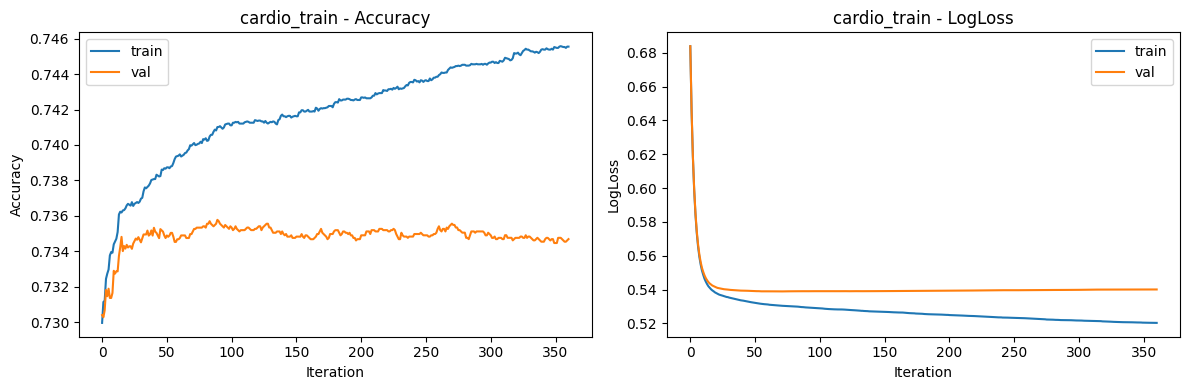

Default metric period is 5 because AUC is/are not implemented for GPU


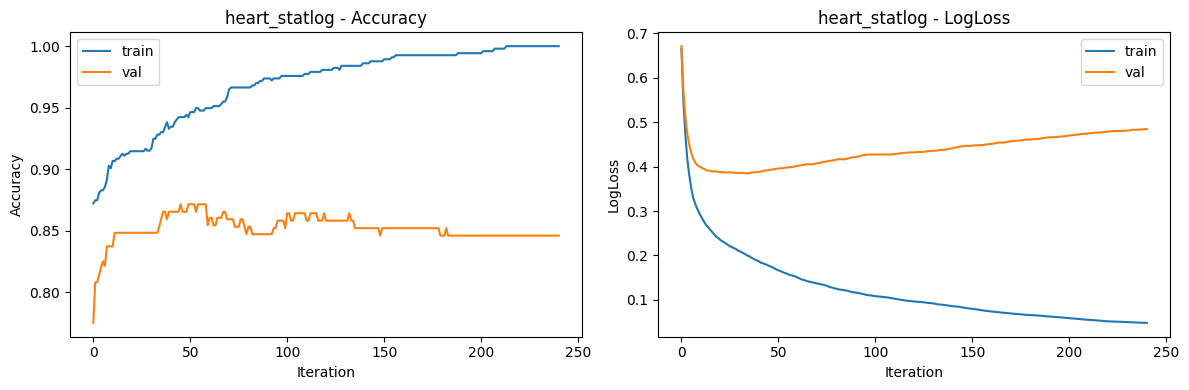

Default metric period is 5 because AUC is/are not implemented for GPU


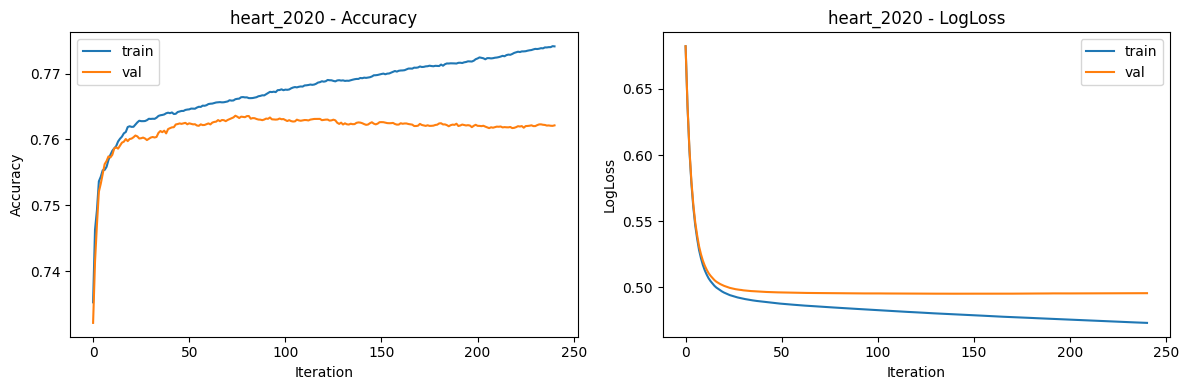

In [8]:
import matplotlib.pyplot as plt

def _train_val_split_for_curves(X, y, seed=SEED):
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=seed
    )
    return X_train, X_val, y_train, y_val

def plot_curves_for_dataset(X, y, dataset_name, best_params):
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    X_train, X_val, y_train, y_val = _train_val_split_for_curves(X, y, seed=SEED)

    model = CatBoostClassifier(
        **best_params,
        loss_function="Logloss",
        eval_metric="Accuracy",
        custom_metric=["AUC", "Logloss"],
        auto_class_weights="Balanced",
        task_type="GPU",
        devices="0",
        random_seed=SEED,
        verbose=False
    )

    model.fit(
        Pool(X_train, y_train, cat_features=cat_idx),
        eval_set=Pool(X_val, y_val, cat_features=cat_idx),
        use_best_model=False
    )

    evals = model.get_evals_result()
    acc_train = evals["learn"]["Accuracy"]
    acc_val = evals["validation"]["Accuracy"]
    ll_train = evals["learn"]["Logloss"]
    ll_val = evals["validation"]["Logloss"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(acc_train, label="train")
    axes[0].plot(acc_val, label="val")
    axes[0].set_title(f"{dataset_name} - Accuracy")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(ll_train, label="train")
    axes[1].plot(ll_val, label="val")
    axes[1].set_title(f"{dataset_name} - LogLoss")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("LogLoss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

best_params_map = {m["dataset"]: m["best_params"] for m in all_metrics}

for ds_name, ds_path in DATA_PATHS.items():
    X, y, canonical = load_dataset_by_name(ds_name, ds_path)
    plot_curves_for_dataset(X, y, canonical, best_params_map[canonical])

## Section 2: Calibrated Stacking (XGBoost + CatBoost + LightGBM)


In [12]:
# Cell 9: Stacking imports + helpers (keeps existing cells intact)
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from catboost import CatBoostClassifier
try:
    import xgboost as xgb
except ImportError:
    xgb = None
    print("xgboost not installed. Install to run stacking: pip install xgboost")

try:
    import lightgbm as lgb
except ImportError:
    lgb = None
    print("lightgbm not installed. Install to run stacking: pip install lightgbm")
import pandas as pd 


In [13]:
def _prepare_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)
    return X

In [14]:
def _build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )

In [15]:
def _make_xgb_pipeline(X: pd.DataFrame, seed: int, use_gpu: bool = True) -> Pipeline:
    tree_method = "gpu_hist" if use_gpu else "hist"
    predictor = "gpu_predictor" if use_gpu else "cpu_predictor"

    model = xgb.XGBClassifier(
        n_estimators=800,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method=tree_method,
        predictor=predictor,
        random_state=seed,
    )
    return Pipeline(
        steps=[
            ("prep", _build_preprocessor(X)),
            ("model", model),
        ]
    )

In [16]:
def _make_lgbm_pipeline(X: pd.DataFrame, seed: int, use_gpu: bool = True) -> Pipeline:
    device = "gpu" if use_gpu else "cpu"

    model = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary",
        device=device,
        random_state=seed,
    )

    return Pipeline(
        steps=[
            ("prep", _build_preprocessor(X)),
            ("model", model),
        ]
    )


In [17]:
def _make_catboost(seed: int) -> CatBoostClassifier:
    return CatBoostClassifier(
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=7,
        iterations=1500,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        task_type="GPU",
        devices="0",
        random_seed=seed,
        verbose=False,
    )

In [31]:
# Cell 10: Stacking pipeline (XGBoost + CatBoost + LightGBM) with calibration
SEED=42
def run_stacking_pipeline(X, y, dataset_name, seed=SEED, verbose=True):
    if xgb is None or lgb is None:
        raise ImportError("xgboost and lightgbm are required for stacking.")

    X = _prepare_features(X)

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=seed
    )

    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    base_names = ["xgb", "cat", "lgbm"]
    oof = np.zeros((len(X_train), len(base_names)), dtype=float)

    xgb_use_gpu = True
    lgbm_use_gpu = True

    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        # XGBoost
        xgb_pipe = _make_xgb_pipeline(X_tr, seed=seed, use_gpu=xgb_use_gpu)
        try:
            xgb_pipe.fit(X_tr, y_tr)
        except Exception:
            xgb_use_gpu = False
            xgb_pipe = _make_xgb_pipeline(X_tr, seed=seed, use_gpu=False)
            xgb_pipe.fit(X_tr, y_tr)
        oof[va_idx, 0] = xgb_pipe.predict_proba(X_va)[:, 1]

        # CatBoost
        cat_model = _make_catboost(seed=seed)
        cat_model.fit(
            Pool(X_tr, y_tr, cat_features=cat_idx),
            eval_set=Pool(X_va, y_va, cat_features=cat_idx),
            use_best_model=True,
            early_stopping_rounds=100,
        )
        oof[va_idx, 1] = cat_model.predict_proba(X_va)[:, 1]

        # LightGBM
        lgbm_pipe = _make_lgbm_pipeline(X_tr, seed=seed, use_gpu=lgbm_use_gpu)
        try:
            lgbm_pipe.fit(X_tr, y_tr)
        except Exception:
            lgbm_use_gpu = False
            lgbm_pipe = _make_lgbm_pipeline(X_tr, seed=seed, use_gpu=False)
            lgbm_pipe.fit(X_tr, y_tr)
        oof[va_idx, 2] = lgbm_pipe.predict_proba(X_va)[:, 1]

        if verbose:
            print(f"{dataset_name} | fold {fold_idx}/5 done")

    meta_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)
    meta_model.fit(oof, y_train)

    # Fit base models on full training data
    xgb_final = _make_xgb_pipeline(X_train, seed=seed, use_gpu=xgb_use_gpu)
    xgb_final.fit(X_train, y_train)

    cat_final = _make_catboost(seed=seed)
    cat_final.fit(
        Pool(X_train, y_train, cat_features=cat_idx),
        eval_set=Pool(X_val, y_val, cat_features=cat_idx),
        use_best_model=True,
        early_stopping_rounds=150,
    )

    lgbm_final = _make_lgbm_pipeline(X_train, seed=seed, use_gpu=lgbm_use_gpu)
    lgbm_final.fit(X_train, y_train)

    # Meta features for validation and test
    val_feats = np.column_stack([
        xgb_final.predict_proba(X_val)[:, 1],
        cat_final.predict_proba(X_val)[:, 1],
        lgbm_final.predict_proba(X_val)[:, 1],
    ])

    test_feats = np.column_stack([
        xgb_final.predict_proba(X_test)[:, 1],
        cat_final.predict_proba(X_test)[:, 1],
        lgbm_final.predict_proba(X_test)[:, 1],
    ])

    # Calibrate meta-model on validation
    calibrator = CalibratedClassifierCV(meta_model, method="isotonic", cv="prefit")
    calibrator.fit(val_feats, y_val)

    val_prob = calibrator.predict_proba(val_feats)[:, 1]
    thresholds = np.arange(0.30, 0.71, 0.01)
    val_f1s = [f1_score(y_val, (val_prob >= t).astype(int)) for t in thresholds]
    best_threshold = float(thresholds[int(np.argmax(val_f1s))])

    test_prob = calibrator.predict_proba(test_feats)[:, 1]
    test_pred = (test_prob >= best_threshold).astype(int)

    metrics = {
        "dataset": dataset_name,
        "model": "stacking",
        "n_rows": int(len(X)),
        "n_features": int(X.shape[1]),
        "val_best_threshold": round(best_threshold, 2),
        "test_accuracy": round(accuracy_score(y_test, test_pred), 4),
        "test_auc": round(roc_auc_score(y_test, test_prob), 4),
        "test_logloss": round(log_loss(y_test, test_prob, labels=[0, 1]), 4),
        "test_f1": round(f1_score(y_test, test_pred), 4),
    }

    if verbose:
        print("\n" + "=" * 70)
        print(f"STACKING RESULTS: {dataset_name}")
        print(pd.Series(metrics))
        print("=" * 70)

    models = {
        "xgb": xgb_final,
        "cat": cat_final,
        "lgbm": lgbm_final,
        "meta": meta_model,
        "calibrator": calibrator,
        "xgb_use_gpu": xgb_use_gpu,
        "lgbm_use_gpu": lgbm_use_gpu,
    }

    return models, metrics

In [33]:
# Cell 11: Run stacking for all datasets + compare vs baseline
stack_metrics = []
stack_models = {}

for ds_name, ds_path in DATA_PATHS.items():
    X, y, canonical_name = load_dataset_by_name(ds_name, ds_path)
    models, m = run_stacking_pipeline(X, y, canonical_name, verbose=True)
    stack_models[canonical_name] = models
    stack_metrics.append(m)

stack_results_df = (
    pd.DataFrame(stack_metrics)
    .sort_values("test_auc", ascending=False)
    .reset_index(drop=True)
)

print("\nStacking leaderboard:")
display(
    stack_results_df[
        [
            "dataset",
            "test_accuracy",
            "test_auc",
            "test_logloss",
            "test_f1",
            "val_best_threshold",
        ]
    ]
)

# Baseline vs stacking comparison (only if baseline exists)
if "results_df" in globals():
    baseline = results_df.copy()
    baseline["model"] = "catboost"

    compare_df = (
        pd.concat([baseline, stack_results_df], ignore_index=True)
        .sort_values(["dataset", "model"], ascending=[True, True])
        .reset_index(drop=True)
    )

    print("\nBaseline vs stacking:")
    display(
        compare_df[
            [
                "dataset",
                "model",
                "test_accuracy",
                "test_auc",
                "test_logloss",
                "test_f1",
                "val_best_threshold",
            ]
        ]
    )
else:
    print("Baseline results not found. Run the baseline leaderboard cell first.")

Default metric period is 5 because AUC is/are not implemented for GPU


[LightGBM] [Info] Number of positive: 16278, number of negative: 16618
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1318
[LightGBM] [Info] Number of data points in the train set: 32896, number of used features: 15
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.38 MB) transferred to GPU in 0.003497 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494832 -> initscore=-0.020672
[LightGBM] [Info] Start training from score -0.020672
cardio_train | fold 1/5 done


Default metric period is 5 because AUC is/are not implemented for GPU


[LightGBM] [Info] Number of positive: 16279, number of negative: 16618
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1312
[LightGBM] [Info] Number of data points in the train set: 32897, number of used features: 15
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.38 MB) transferred to GPU in 0.004220 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494848 -> initscore=-0.020611
[LightGBM] [Info] Start training from score -0.020611
cardio_train | fold 2/5 done


Default metric period is 5 because AUC is/are not implemented for GPU


...

[LightGBM] [Info] Number of positive: 13086, number of negative: 131738
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 431
[LightGBM] [Info] Number of data points in the train set: 144824, number of used features: 50
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 6 dense feature groups (1.10 MB) transferred to GPU in 0.004816 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090358 -> initscore=-2.309272
[LightGBM] [Info] Start training from score -2.309272
heart_2020 | fold 5/5 done


Default metric period is 5 because AUC is/are not implemented for GPU


[LightGBM] [Info] Number of positive: 16357, number of negative: 164672
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 431
[LightGBM] [Info] Number of data points in the train set: 181029, number of used features: 50
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 6 dense feature groups (1.38 MB) transferred to GPU in 0.010468 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090356 -> initscore=-2.309300
[LightGBM] [Info] Start training from score -2.309300

STACKING RESULTS: heart_2020
dataset               heart_2020
model                   stacking
n_rows                    301717
n_features                    17
val_best_threshold           0.3
test_accuracy             0.8986
test_auc                 

,dataset,test_accuracy,test_auc,test_logloss,test_f1,val_best_threshold
0,heart_statlog,0.8804,0.9347,0.4917,0.8942,0.30
1,heart_2020,0.8986,0.8359,0.2368,0.3497,0.30
2,cardio_train,0.7036,0.7982,0.5471,0.7367,0.35


Baseline results not found. Run the baseline leaderboard cell first.


## Section 3: (SMOTEENN + XGB/LGBM/RF Stacking)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, mean_absolute_error, 
    mean_squared_error, r2_score
)
from imblearn.combine import SMOTEENN
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

In [ ]:
SEED = 42
DATA_PATHS = {
    "heart_2020": "heart_2020_cleaned.csv",
    "cardio_train": "cardio_train.csv", 
    "heart_statlog": "heart_statlog_cleveland_hungary_final.csv"
}

In [ ]:
def remove_outliers_iqr(df):
    """Removes outliers using the IQR approach as per Paper Eq 1 & 2."""
    df_final = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
       
        lower_bound = Q1 - 1.5 * IQR 
        upper_bound = Q3 + 1.5 * IQR
        df_final = df_final[(df_final[col] >= lower_bound) & (df_final[col] <= upper_bound)] 
    return df_final

In [ ]:
def get_preprocessor(X):
    """Creates a transformer for One-Hot Encoding and Scaling."""
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

In [28]:
def tune_models(X_train, y_train):
    """Optimizes base learners using Optuna maximize F1-score."""
    def objective(trial):
        classifier = trial.suggest_categorical("classifier", ["XGB", "LGBM", "RF"])
        
        if classifier == "XGB":
            param = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 800),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "random_state": SEED,
                "use_label_encoder": False,
                "eval_metric": "logloss"
            }
            model = xgb.XGBClassifier(**param)
        elif classifier == "LGBM":
            param = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 800),
                "num_leaves": trial.suggest_int("num_leaves", 31, 127),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
                "random_state": SEED
            }
            model = lgb.LGBMClassifier(**param)
        else: # Random Forest
            param = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 500),
                "max_depth": trial.suggest_int("max_depth", 5, 20),
                "random_state": SEED
            }
            model = RandomForestClassifier(**param)
        
        return cross_val_score(model, X_train, y_train, cv=3, scoring='f1').mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10) # Paper uses more trials for peak accuracy [cite: 510]
    return study.best_params

In [29]:
def run_experiment(X, y, dataset_name):
    print(f"\n>>> Starting Experiment: {dataset_name}")
    
    # Preprocessing: Remove Missing & Outliers [cite: 226, 323]
    X = X.dropna()
    y = y.loc[X.index]
    X = remove_outliers_iqr(X)
    y = y.loc[X.index]
    
    # Train/Test Split [cite: 339, 501]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    
    # Preprocess Features (Scaling & Encoding) [cite: 161]
    preprocessor = get_preprocessor(X_train)
    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)
    
    # SMOTEENN Resampling [cite: 20, 84, 483]
    sme = SMOTEENN(random_state=SEED)
    X_res, y_res = sme.fit_resample(X_train_proc, y_train)
    print(f"Original shape: {X_train_proc.shape}, Resampled shape: {X_res.shape}")

    # Define Stacking Ensemble [cite: 72, 83, 493]
    base_learners = [
        ('xgb', xgb.XGBClassifier(random_state=SEED)),
        ('lgbm', lgb.LGBMClassifier(random_state=SEED)),
        ('rf', RandomForestClassifier(random_state=SEED))
    ]
    meta_learner = LogisticRegression(class_weight='balanced') 
    
    stack_model = StackingClassifier(
        estimators=base_learners, 
        final_estimator=meta_learner, 
        cv=5, 
        passthrough=False 
    )
    
    # Train
    stack_model.fit(X_res, y_res)
    
    # Predict
    y_pred = stack_model.predict(X_test_proc)
    y_prob = stack_model.predict_proba(X_test_proc)[:, 1]
    
    # Evaluation Metrics [cite: 507, 645]
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "MAE": mean_absolute_error(y_test, y_prob),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_prob)),
        "R2": r2_score(y_test, y_prob)
    }
    
    # Plotting: Confusion Matrix [cite: 733]
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {dataset_name}")
    
    # Plotting: ROC Curve [cite: 951, 979]
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'AUC = {metrics["AUC"]:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve - {dataset_name}")
    plt.legend()
    plt.show()


    joblib.dump(stack_model, f"stacking_model_{dataset_name}.pkl")
    print(pd.Series(metrics))
    return metrics


>>> Starting Experiment: heart_2020
Original shape: (184816, 50), Resampled shape: (274851, 50)
[LightGBM] [Info] Number of positive: 143859, number of negative: 130992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 274851, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.523407 -> initscore=0.093697
[LightGBM] [Info] Start training from score 0.093697
[LightGBM] [Info] Number of positive: 115087, number of negative: 104793
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12750
[LightGBM

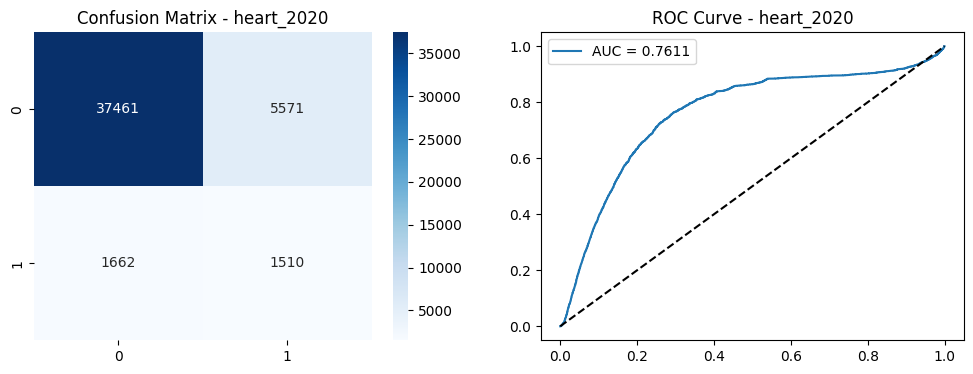

Accuracy     0.843455
Precision    0.213247
Recall       0.476040
F1-Score     0.294548
AUC          0.761131
MAE          0.165897
RMSE         0.368313
R2          -1.121629
dtype: float64

>>> Starting Experiment: cardio_train
Original shape: (30418, 12), Resampled shape: (11968, 12)
[LightGBM] [Info] Number of positive: 6397, number of negative: 5571
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1255
[LightGBM] [Info] Number of data points in the train set: 11968, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.534509 -> initscore=0.138255
[LightGBM] [Info] Start training from score 0.138255
[LightGBM] [Info] Number of positive: 5118, number of negative: 4456
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.00

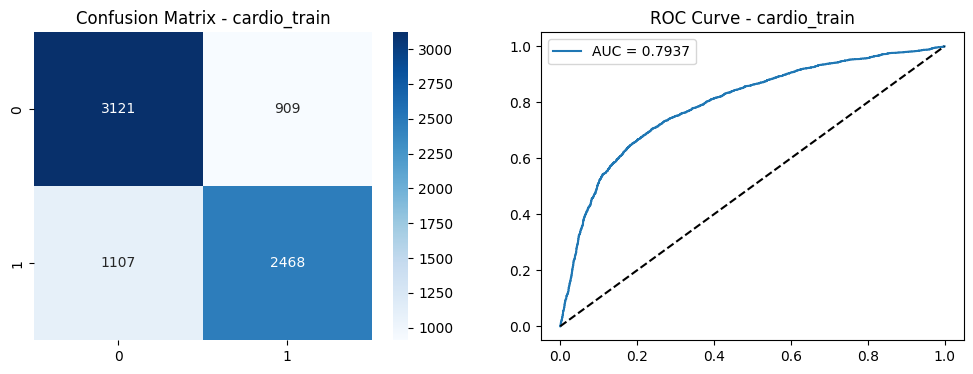

Accuracy     0.734911
Precision    0.730826
Recall       0.690350
F1-Score     0.710012
AUC          0.793684
MAE          0.277489
RMSE         0.477515
R2           0.084640
dtype: float64

>>> Starting Experiment: heart_statlog
Original shape: (447, 11), Resampled shape: (324, 11)
[LightGBM] [Info] Number of positive: 153, number of negative: 171
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 260
[LightGBM] [Info] Number of data points in the train set: 324, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.472222 -> initscore=-0.111226
[LightGBM] [Info] Start training from score -0.111226
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

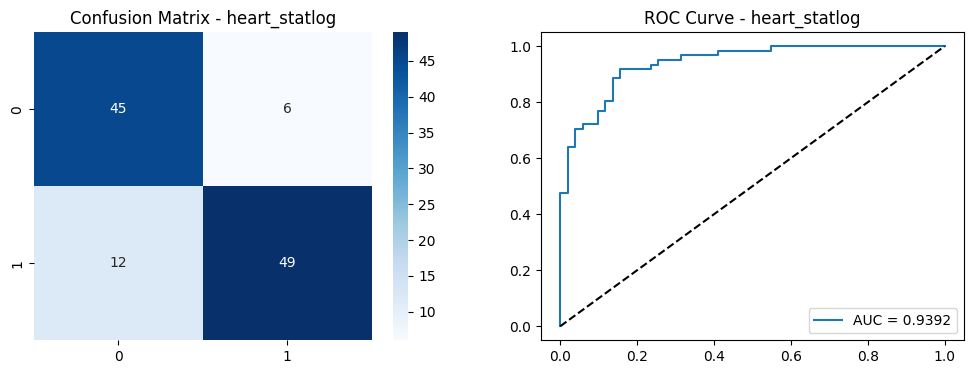

Accuracy     0.839286
Precision    0.890909
Recall       0.803279
F1-Score     0.844828
AUC          0.939248
MAE          0.179876
RMSE         0.377182
R2           0.426362
dtype: float64

FINAL SUMMARY TABLE:
               Accuracy  Precision    Recall  F1-Score       AUC       MAE  \
heart_2020     0.843455   0.213247  0.476040  0.294548  0.761131  0.165897   
cardio_train   0.734911   0.730826  0.690350  0.710012  0.793684  0.277489   
heart_statlog  0.839286   0.890909  0.803279  0.844828  0.939248  0.179876   

                   RMSE        R2  
heart_2020     0.368313 -1.121629  
cardio_train   0.477515  0.084640  
heart_statlog  0.377182  0.426362  


In [30]:
all_results = []
for name, path in DATA_PATHS.items():
    if not Path(path).exists(): continue
    
    # Load specific formats [cite: 147]
    sep = ';' if 'cardio' in name else ','
    df = pd.read_csv(path, sep=sep)
    
    # Standardize target names [cite: 148, 152, 153]
    target_col = 'cardio' if 'cardio' in name else ('HeartDisease' if '2020' in name else 'target')
    X = df.drop(columns=[target_col])
    y = df[target_col].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
    
    res = run_experiment(X, y, name)
    all_results.append(res)

# Summary table [cite: 647]
final_df = pd.DataFrame(all_results, index=DATA_PATHS.keys()).dropna()
print("\nFINAL SUMMARY TABLE:")
print(final_df)

## Section 4: Rigorous OOF + 4-Model Stack (XGBoost + LightGBM + RandomForest + CatBoost)


In [41]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, f1_score, average_precision_score

from imblearn.combine import SMOTEENN
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')

SEED = 42

In [42]:
def remove_outliers_iqr(df):
    """Removes extreme outliers strictly to prevent gradient boosting noise."""
    df_clean = df.copy()
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= (Q1 - 1.5 * IQR)) & (df_clean[col] <= (Q3 + 1.5 * IQR))]
    return df_clean

In [43]:
def add_domain_features(X):
    X = X.copy()
    cols = {c.lower(): c for c in X.columns}
    
    if "height" in cols and "weight" in cols:
        h = X[cols["height"]] / 100.0
        X["bmi"] = X[cols["weight"]] / (h.pow(2).replace(0, np.nan))
    
    if "ap_hi" in cols and "ap_lo" in cols:
        X["pulse_pressure"] = X[cols["ap_hi"]] - X[cols["ap_lo"]]
        X["map"] = X[cols["ap_lo"]] + (X["pulse_pressure"] / 3.0)
        
    return X

In [44]:
def get_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

In [ ]:
def _best_threshold(y_true, prob):
    """Safely calculates the optimal threshold for F1-Score."""
    thresholds = np.arange(0.10, 0.90, 0.01)
    f1_scores = [f1_score(y_true, (prob >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1_scores))
    
    best_t = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])
   
    return best_t, best_f1, 0.0

In [50]:
def run_rigorous_stacking(X, y, dataset_name):
    print(f"\n{'='*70}\nStarting Rigorous Evaluation: {dataset_name}\n{'='*70}")
    
    # 1. Feature Engineering & Outliers
    X = add_domain_features(X)
    X = remove_outliers_iqr(X)
    y = y.loc[X.index]
    
    # 2. Strict Train/Test Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    
    # 3. Preprocessing
    prep = get_preprocessor(X_train)
    X_train_proc = prep.fit_transform(X_train)
    X_test_proc = prep.transform(X_test)
    
    # 4. Out-Of-Fold (OOF) Setup
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros((X_train_proc.shape[0], 4)) # 4 Base Models
    
    # --- CROSS VALIDATION LOOP (Leakage-Free) ---
    print("Generating OOF Predictions (Applying SMOTEENN inside folds)...")
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_proc, y_train)):
        X_tr, X_va = X_train_proc[tr_idx], X_train_proc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        
        # Apply SMOTEENN ONLY to the training fold
        sme = SMOTEENN(random_state=SEED)
        X_tr_res, y_tr_res = sme.fit_resample(X_tr, y_tr)
        
        # Initialize Models (Fast Defaults)
        models = [
            xgb.XGBClassifier(tree_method="hist",device="cuda", max_depth=5, random_state=SEED),
            lgb.LGBMClassifier(device="gpu", num_leaves=31, random_state=SEED),
            RandomForestClassifier(max_depth=10, random_state=SEED),
            CatBoostClassifier(task_type="GPU", depth=6, verbose=False, random_state=SEED)
        ]
        
        # Train and Predict for this fold
        for i, model in enumerate(models):
            model.fit(X_tr_res, y_tr_res)
            oof_preds[va_idx, i] = model.predict_proba(X_va)[:, 1]
            
        print(f"Fold {fold+1}/5 Complete.")

    # 5. Train Meta-Model on OOF Predictions
    print("Training Meta-Model...")
    meta_model = LogisticRegression(class_weight="balanced", random_state=SEED)
    meta_model.fit(oof_preds, y_train)
    calibrated_meta = CalibratedClassifierCV(meta_model, method="isotonic", cv="prefit")
    calibrated_meta.fit(oof_preds, y_train)
    
    # Calculate Optimal Threshold on OOF data
    val_probs = calibrated_meta.predict_proba(oof_preds)[:, 1]
    best_t, best_f1_val, _ = _best_threshold(y_train, val_probs)
    print(f"Optimal F1 Threshold found: {best_t:.2f} (OOF F1: {best_f1_val:.4f})")

    # 6. Final Train on FULL Train Data (Apply SMOTEENN to full train set)
    print("Training Final Base Models on Full Train Set...")
    X_train_res, y_train_res = SMOTEENN(random_state=SEED).fit_resample(X_train_proc, y_train)
    
    final_models = [
        xgb.XGBClassifier(tree_method="hist",device="cuda", max_depth=5, random_state=SEED).fit(X_train_res, y_train_res),
        lgb.LGBMClassifier(device="gpu", num_leaves=31, random_state=SEED).fit(X_train_res, y_train_res),
        RandomForestClassifier(max_depth=10, random_state=SEED).fit(X_train_res, y_train_res),
        CatBoostClassifier(task_type="GPU", depth=6, verbose=False, random_state=SEED).fit(X_train_res, y_train_res)
    ]
    
    # 7. Final Test Evaluation
    print("Evaluating on Untouched Test Set...")
    test_feats = np.column_stack([m.predict_proba(X_test_proc)[:, 1] for m in final_models])
    test_probs = calibrated_meta.predict_proba(test_feats)[:, 1]
    test_preds = (test_probs >= best_t).astype(int)
    
    metrics = {
        "Dataset": dataset_name,
        "Test AUC": round(roc_auc_score(y_test, test_probs), 4),
        "Test F1": round(f1_score(y_test, test_preds), 4),
        "Test Accuracy": round(accuracy_score(y_test, test_preds), 4),
        "Optimal Threshold": best_t
    }
    
    print("-" * 30)
    for k, v in metrics.items():
        print(f"{k}: {v}")
    
    return metrics

In [51]:
all_honest_metrics = []
for name, path in DATA_PATHS.items():
    if Path(path).exists():
        sep = ';' if 'cardio' in name else ','
        df = pd.read_csv(path, sep=sep)
        target_col = 'cardio' if 'cardio' in name else ('HeartDisease' if '2020' in name else 'target')
        
        X = df.drop(columns=[target_col])
        y = df[target_col].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(df[target_col]).astype(int)
        
        m = run_rigorous_stacking(X, y, name)
        all_honest_metrics.append(m)

print("\nFINAL HONEST LEADERBOARD:")
display(pd.DataFrame(all_honest_metrics))


Starting Rigorous Evaluation: heart_2020
Generating OOF Predictions (Applying SMOTEENN inside folds)...
[LightGBM] [Info] Number of positive: 113339, number of negative: 102198
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 215537, number of used features: 50
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 6 dense feature groups (1.64 MB) transferred to GPU in 0.006303 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.525845 -> initscore=0.103471
[LightGBM] [Info] Start training from score 0.103471
Fold 1/5 Complete.
[LightGBM] [Info] Number of positive: 113485, number of negative: 101852
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] 

,Dataset,Test AUC,Test F1,Test Accuracy,Optimal Threshold
0,heart_2020,0.8248,0.3365,0.8748,0.18
1,cardio_train,0.6847,0.5590,0.5909,0.26
2,heart_statlog,0.9396,0.8667,0.8584,0.34



Generating SHAP Explainability for heart_2020...
Calculating SHAP values (this may take a minute for large datasets)...


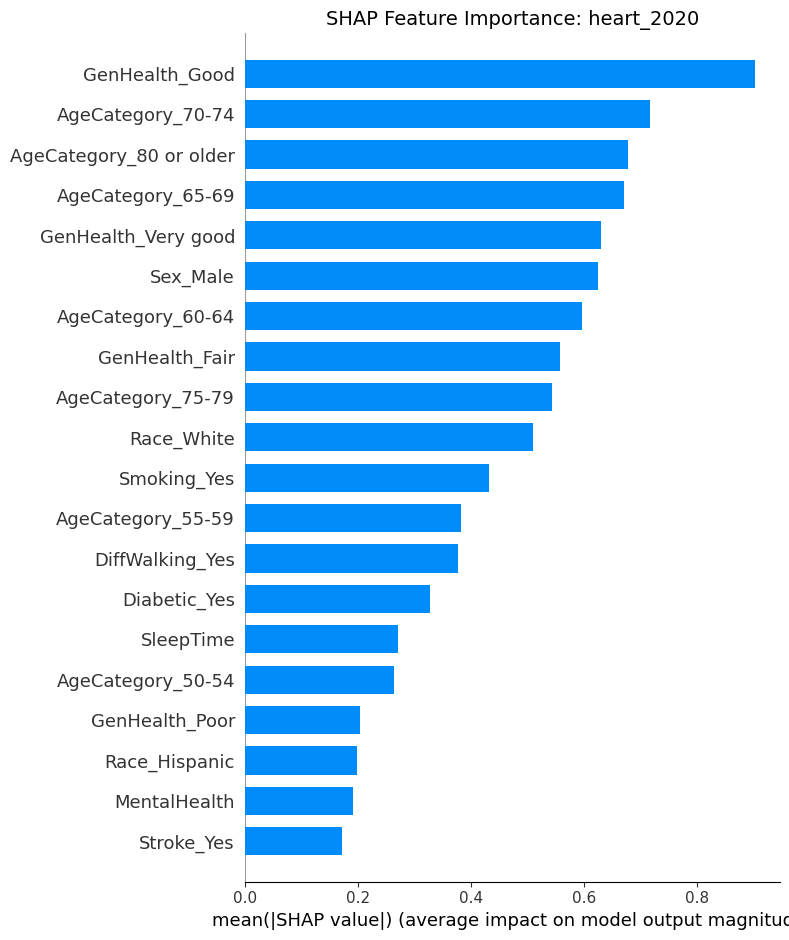


Generating SHAP Explainability for cardio_train...
Calculating SHAP values (this may take a minute for large datasets)...


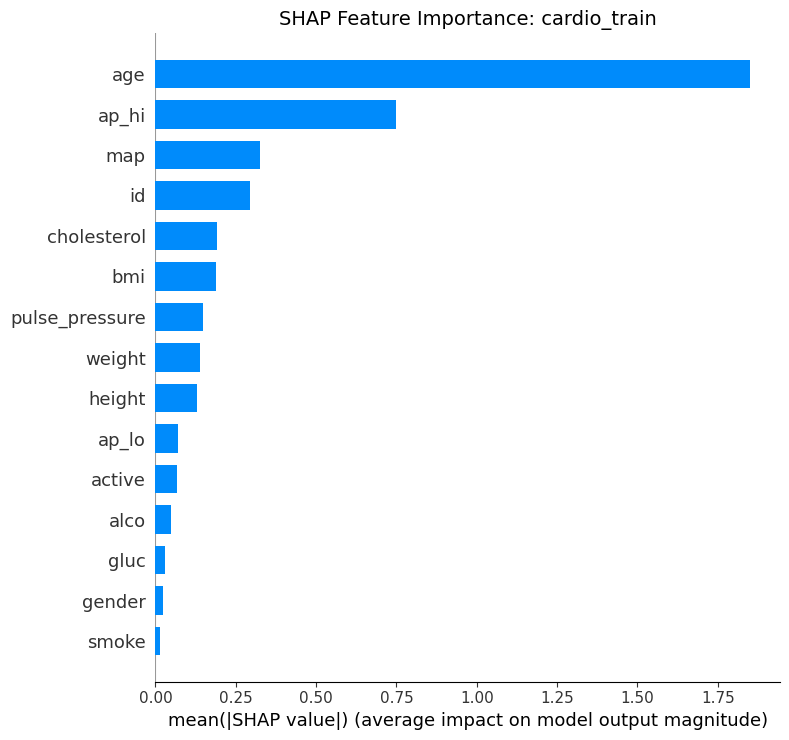


Generating SHAP Explainability for heart_statlog...
Calculating SHAP values (this may take a minute for large datasets)...


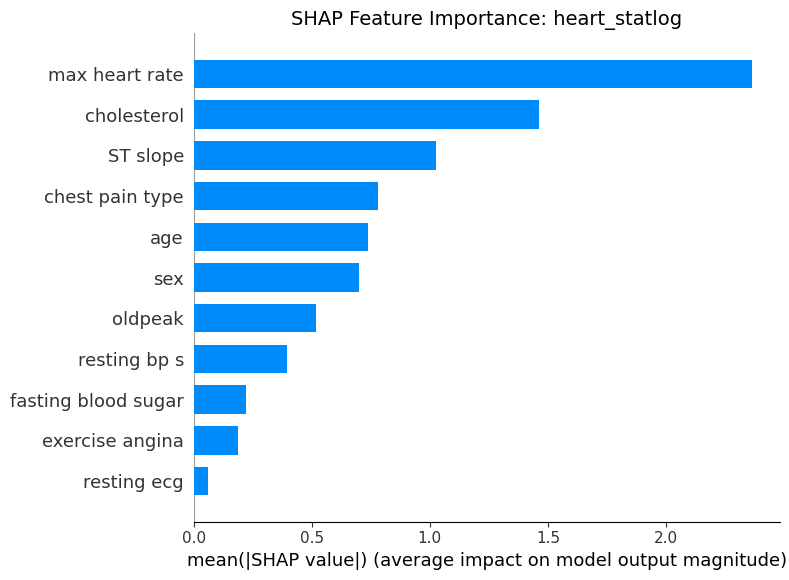

In [52]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.combine import SMOTEENN
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Helper function to train a clean model for SHAP
def generate_shap_explanations(dataset_name, path):
    print(f"\nGenerating SHAP Explainability for {dataset_name}...")
    
    # Load and prep data
    sep = ';' if 'cardio' in dataset_name else ','
    df = pd.read_csv(path, sep=sep)
    target_col = 'cardio' if 'cardio' in dataset_name else ('HeartDisease' if '2020' in dataset_name else 'target')
    
    X = df.drop(columns=[target_col])
    y = df[target_col].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(df[target_col]).astype(int)
    
    # Add domain features (from our rigorous pipeline)
    cols = {c.lower(): c for c in X.columns}
    if "height" in cols and "weight" in cols:
        h = X[cols["height"]] / 100.0
        X["bmi"] = X[cols["weight"]] / (h.pow(2).replace(0, np.nan))
    if "ap_hi" in cols and "ap_lo" in cols:
        X["pulse_pressure"] = X[cols["ap_hi"]] - X[cols["ap_lo"]]
        X["map"] = X[cols["ap_lo"]] + (X["pulse_pressure"] / 3.0)
    
    # Simple preprocessing for SHAP (Keep categorical names for readability)
    X_encoded = pd.get_dummies(X, drop_first=True)
    
    # Train/Test Split & SMOTEENN
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)
    X_train_res, y_train_res = SMOTEENN(random_state=42).fit_resample(X_train, y_train)
    
    # Train the XGBoost model (Tree models are best for SHAP)
    xgb_model = xgb.XGBClassifier(tree_method="hist", max_depth=5, random_state=42)
    xgb_model.fit(X_train_res, y_train_res)
    
    # 2. Calculate SHAP Values
    print("Calculating SHAP values (this may take a minute for large datasets)...")
    explainer = shap.TreeExplainer(xgb_model)
    
    # For speed on the massive 2020 dataset, we sample the background
    if len(X_test) > 5000:
        X_test_sample = X_test.sample(5000, random_state=42)
    else:
        X_test_sample = X_test
        
    shap_values = explainer.shap_values(X_test_sample)
    
    # 3. Plot exactly like the paper (Summary Bar Plot)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance: {dataset_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# --- RUN SHAP FOR ALL DATASETS ---
# Ensure DATA_PATHS is still defined in your environment
for name, path in DATA_PATHS.items():
    if Path(path).exists():
        generate_shap_explanations(name, path)

heart_statlog with the optuna with all the hyperparameters

## Section 5: Dataset-Specific Optuna-Tuned Expert Pipelines + Consensus Voting


In [54]:
import pandas as pd
import numpy as np
import warnings
import optuna
import joblib  # <-- Added for saving the model
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             precision_score, recall_score, 
                             mean_absolute_error, mean_squared_error, r2_score)

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Disable Optuna spam and standard warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

# --- 1. DATA PREP & FEATURE ENGINEERING ---

def remove_outliers_iqr(df):
    df_clean = df.copy()
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= (Q1 - 1.5 * IQR)) & (df_clean[col] <= (Q3 + 1.5 * IQR))]
    return df_clean

def add_domain_features(X):
    X = X.copy()
    cols = {c.lower(): c for c in X.columns}
    if "height" in cols and "weight" in cols:
        h = X[cols["height"]] / 100.0
        X["bmi"] = X[cols["weight"]] / (h.pow(2).replace(0, np.nan))
    if "ap_hi" in cols and "ap_lo" in cols:
        X["pulse_pressure"] = X[cols["ap_hi"]] - X[cols["ap_lo"]]
        X["map"] = X[cols["ap_lo"]] + (X["pulse_pressure"] / 3.0)
    return X

def get_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# --- 2. THRESHOLD TUNING ---

def _best_threshold(y_true, prob, optimize_for="f1"):
    thresholds = np.arange(0.10, 0.90, 0.01)
    if optimize_for == "f1":
        scores = [f1_score(y_true, (prob >= t).astype(int)) for t in thresholds]
    else: 
        scores = [accuracy_score(y_true, (prob >= t).astype(int)) for t in thresholds]
        
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx]), 0.0 

# --- 3. OPTUNA TUNING (LEAKAGE-FREE & PAPER HYPERPARAMETERS) ---

def tune_hyperparameters(X_train, y_train, is_imbalanced, n_trials=30):
    print(f"  -> Tuning models using Optuna ({n_trials} trials per model)...")
    scorer = 'f1' if is_imbalanced else 'accuracy'
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED) 
    
    # 1. XGBoost Tuning
    def xgb_objective(trial):
        param = {
            "tree_method": "hist",
            "device": "cuda",
            "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
        }
        model = xgb.XGBClassifier(**param)
        pipe = ImbPipeline([('smote', SMOTEENN(random_state=SEED)), ('model', model)]) if is_imbalanced else ImbPipeline([('model', model)])
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    # 2. LightGBM Tuning
    def lgb_objective(trial):
        param = {
            "device": "gpu",
            "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
            "min_child_samples": trial.suggest_int("min_child_samples", 1, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
        }
        model = lgb.LGBMClassifier(**param)
        pipe = ImbPipeline([('smote', SMOTEENN(random_state=SEED)), ('model', model)]) if is_imbalanced else ImbPipeline([('model', model)])
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    # 3. Random Forest Tuning
    def rf_objective(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 5, 20),
            "random_state": SEED,
            "n_jobs": -1
        }
        model = RandomForestClassifier(**param)
        pipe = ImbPipeline([('smote', SMOTEENN(random_state=SEED)), ('model', model)]) if is_imbalanced else ImbPipeline([('model', model)])
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    # Run Optuna
    xgb_study = optuna.create_study(direction="maximize")
    xgb_study.optimize(xgb_objective, n_trials=n_trials)
    
    lgb_study = optuna.create_study(direction="maximize")
    lgb_study.optimize(lgb_objective, n_trials=n_trials)
    
    rf_study = optuna.create_study(direction="maximize")
    rf_study.optimize(rf_objective, n_trials=n_trials)
    
    # Extract Best Params
    xgb_tuned = xgb.XGBClassifier(**xgb_study.best_params, tree_method="hist", device="cuda", random_state=SEED)
    lgb_tuned = lgb.LGBMClassifier(**lgb_study.best_params, device="gpu", random_state=SEED)
    rf_tuned = RandomForestClassifier(**rf_study.best_params, random_state=SEED, n_jobs=-1)
    cat_tuned = CatBoostClassifier(task_type="GPU", depth=6, verbose=False, random_state=SEED)
    
    return [xgb_tuned, lgb_tuned, rf_tuned, cat_tuned]

# --- 4. RIGOROUS & SMART STACKING PIPELINE ---

def run_rigorous_tuned_stacking(X, y, dataset_name):
    print(f"\n{'='*70}\nStarting Rigorous Tuned Evaluation: {dataset_name}\n{'='*70}")
    
    X = add_domain_features(X)
    X = remove_outliers_iqr(X)
    y = y.loc[X.index]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    
    # Strategy Check
    imbalance_ratio = y_train.value_counts().min() / y_train.value_counts().max()
    is_imbalanced = imbalance_ratio < 0.30
    target_metric = "f1" if is_imbalanced else "accuracy"
    
    print(f"Dataset Ratio: {imbalance_ratio:.2f} | Strategy: {'SMOTE+F1' if is_imbalanced else 'Clean+Acc'}")

    prep = get_preprocessor(X_train)
    X_train_proc = prep.fit_transform(X_train)
    X_test_proc = prep.transform(X_test)
    
    # ---- 1. RUN OPTUNA TUNING ----
    tuned_models = tune_hyperparameters(X_train_proc, y_train, is_imbalanced, n_trials=30)
    
    # ---- 2. OOF PREDICTIONS ----
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros((X_train_proc.shape[0], 4)) 
    
    print("  -> Generating OOF Predictions...")
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_proc, y_train)):
        X_tr, X_va = X_train_proc[tr_idx], X_train_proc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        
        if is_imbalanced:
            X_tr_fit, y_tr_fit = SMOTEENN(random_state=SEED).fit_resample(X_tr, y_tr)
        else:
            X_tr_fit, y_tr_fit = X_tr, y_tr
        
        for i, model in enumerate(tuned_models):
            model.fit(X_tr_fit, y_tr_fit)
            oof_preds[va_idx, i] = model.predict_proba(X_va)[:, 1]

    # ---- 3. META-MODEL TRAINING ----
    print("  -> Training Calibrated Meta-Model...")
    cw = "balanced" if is_imbalanced else None
    meta_model = LogisticRegression(class_weight=cw, random_state=SEED)
    meta_model.fit(oof_preds, y_train) 
    
    calibrated_meta = CalibratedClassifierCV(meta_model, method="isotonic", cv="prefit")
    calibrated_meta.fit(oof_preds, y_train)
    
    val_probs = calibrated_meta.predict_proba(oof_preds)[:, 1]
    best_t, best_val_score, _ = _best_threshold(y_train, val_probs, optimize_for=target_metric)

    # ---- 4. FINAL TRAIN ON FULL DATA ----
    print("  -> Training Final Ensembles on Full Train Set...")
    if is_imbalanced:
        X_train_final, y_train_final = SMOTEENN(random_state=SEED).fit_resample(X_train_proc, y_train)
    else:
        X_train_final, y_train_final = X_train_proc, y_train
        
    for model in tuned_models:
        model.fit(X_train_final, y_train_final)
    
    # ---- 5. TEST EVALUATION (ALL METRICS) ----
    test_feats = np.column_stack([m.predict_proba(X_test_proc)[:, 1] for m in tuned_models])
    test_probs = calibrated_meta.predict_proba(test_feats)[:, 1]
    test_preds = (test_probs >= best_t).astype(int)
    
    # Calculate regression metrics on predictions
    mae = mean_absolute_error(y_test, test_preds)
    mse = mean_squared_error(y_test, test_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, test_preds)
    
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": round(accuracy_score(y_test, test_preds), 4),
        "Precision": round(precision_score(y_test, test_preds), 4),
        "Recall": round(recall_score(y_test, test_preds), 4),
        "F1 Score": round(f1_score(y_test, test_preds), 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4),
        "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4),
        "Threshold": best_t
    }
    
    print("\n" + "=" * 40)
    for k, v in metrics.items():
        print(f"{k}: {v}")
    print("=" * 40)
    
    # ---- 6. SAVE THE PIPELINE & MODEL ----
    model_artifact = {
        "preprocessor": prep,
        "base_models": tuned_models,
        "meta_model": calibrated_meta,
        "threshold": best_t,
        "features": X.columns.tolist()
    }
    
    model_filename = f"stacking_model_{dataset_name}.pkl"
    joblib.dump(model_artifact, model_filename)
    print(f"  -> \u2705 Model successfully saved as: {model_filename}")
    
    return metrics

# --- EXECUTION FOR HEART_STATLOG ONLY ---
# Make sure DATA_PATHS is defined above this block
if "heart_statlog" in DATA_PATHS and Path(DATA_PATHS["heart_statlog"]).exists():
    path = DATA_PATHS["heart_statlog"]
    df = pd.read_csv(path, sep=',') 
    
    X = df.drop(columns=['target'])
    y = df['target'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(df['target']).astype(int)
    
    statlog_metrics = run_rigorous_tuned_stacking(X, y, "heart_statlog")
    
    print("\nFINAL RESULTS FOR HEART_STATLOG:")
    display(pd.DataFrame([statlog_metrics]))
else:
    print("Error: Could not find 'heart_statlog' in DATA_PATHS or file does not exist.")


Starting Rigorous Tuned Evaluation: heart_statlog
Dataset Ratio: 0.84 | Strategy: Clean+Acc
  -> Tuning models using Optuna (30 trials per model)...
[LightGBM] [Info] Number of positive: 162, number of negative: 137
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 239
[LightGBM] [Info] Number of data points in the train set: 299, number of used features: 9
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (0.00 MB) transferred to GPU in 0.004715 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.541806 -> initscore=0.167615
[LightGBM] [Info] Start training from score 0.167615
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,Dataset,Accuracy,Precision,Recall,F1 Score,MAE,MSE,RMSE,R2 Score,ROC-AUC,Threshold
0,heart_statlog,0.9469,1.0,0.9032,0.9492,0.0531,0.0531,0.2304,0.7856,0.9941,0.46


for cardio_train 



**************************************************
KICKING OFF OPTUNA PIPELINE FOR: cardio_train
**************************************************

Starting Rigorous Tuned Evaluation: cardio_train
Dataset Ratio: 0.94 | Strategy: Clinical Balance (Youden's Index)
  -> Tuning models using Optuna (50 trials per model)...
[LightGBM] [Info] Number of positive: 16615, number of negative: 17677
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 942
[LightGBM] [Info] Number of data points in the train set: 34292, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (0.39 MB) transferred to GPU in 0.016053 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.484515 -> initsc

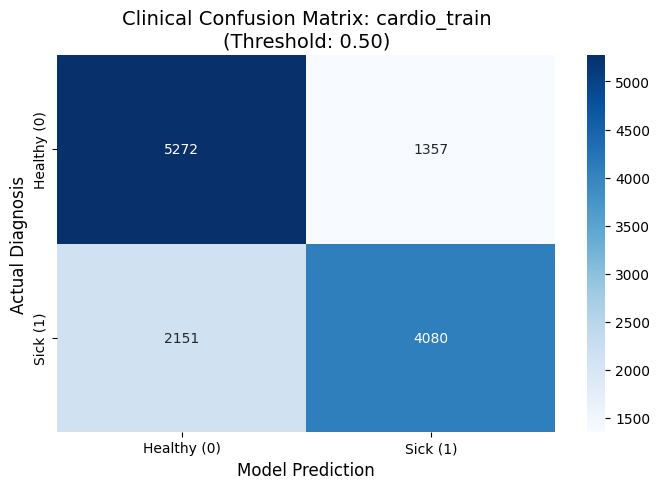


Dataset: cardio_train
Accuracy: 0.7272
Precision: 0.7504
Recall: 0.6548
F1 Score: 0.6993
MAE: 0.2728
MSE: 0.2728
RMSE: 0.5223
R2 Score: -0.0922
ROC-AUC: 0.7949
Threshold: 0.4999999999999998
  -> ✅ Model successfully saved as: stacking_model_cardio_train.pkl

FINAL RESULTS FOR CARDIO_TRAIN:


,Dataset,Accuracy,Precision,Recall,F1 Score,MAE,MSE,RMSE,R2 Score,ROC-AUC,Threshold
0,cardio_train,0.7272,0.7504,0.6548,0.6993,0.2728,0.2728,0.5223,-0.0922,0.7949,0.5


In [63]:
import pandas as pd
import numpy as np
import warnings
import optuna
import joblib 
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             precision_score, recall_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Disable Optuna spam and standard warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

# --- 1. DATA PREP & FEATURE ENGINEERING ---

def remove_outliers_iqr(df):
    df_clean = df.copy()
    
    # 1. First, fix the notorious cardio_train blood pressure typos
    # (Humans cannot have Systolic > 250 or < 80, or Diastolic > 150 or < 50)
    # Systolic (ap_hi) must always be higher than Diastolic (ap_lo)
    if 'ap_hi' in df_clean.columns and 'ap_lo' in df_clean.columns:
        df_clean = df_clean[
            (df_clean['ap_hi'] >= 80) & (df_clean['ap_hi'] <= 250) &
            (df_clean['ap_lo'] >= 50) & (df_clean['ap_lo'] <= 150) &
            (df_clean['ap_hi'] > df_clean['ap_lo']) 
        ]
        
    # 2. ONLY apply IQR math to truly continuous columns, NEVER binary/categorical columns!
    continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'map']
    
    for col in continuous_cols:
        if col in df_clean.columns:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            # We use a slightly wider bounds (2.0 instead of 1.5) to keep more valid medical edge-cases
            df_clean = df_clean[(df_clean[col] >= (Q1 - 2.0 * IQR)) & (df_clean[col] <= (Q3 + 2.0 * IQR))]
            
    return df_clean

def add_domain_features(X):
    X = X.copy()
    cols = {c.lower(): c for c in X.columns}
    if "height" in cols and "weight" in cols:
        h = X[cols["height"]] / 100.0
        X["bmi"] = X[cols["weight"]] / (h.pow(2).replace(0, np.nan))
    if "ap_hi" in cols and "ap_lo" in cols:
        X["pulse_pressure"] = X[cols["ap_hi"]] - X[cols["ap_lo"]]
        X["map"] = X[cols["ap_lo"]] + (X["pulse_pressure"] / 3.0)
    return X

def get_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# --- 2. THRESHOLD TUNING (NOW USING YOUDEN'S CLINICAL INDEX) ---

def _best_threshold(y_true, prob, optimize_for="youden"):
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_t = 0.5
    best_score = 0.0
    
    if optimize_for == "f1":
        scores = [f1_score(y_true, (prob >= t).astype(int)) for t in thresholds]
        best_idx = int(np.argmax(scores))
        best_t, best_score = float(thresholds[best_idx]), float(scores[best_idx])
        
    elif optimize_for == "accuracy": 
        scores = [accuracy_score(y_true, (prob >= t).astype(int)) for t in thresholds]
        best_idx = int(np.argmax(scores))
        best_t, best_score = float(thresholds[best_idx]), float(scores[best_idx])
        
    elif optimize_for == "youden":
        # Calculates the perfect balance between Sensitivity and Specificity
        best_j = -1
        for t in thresholds:
            preds = (prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            j_stat = sensitivity + specificity - 1
            
            if j_stat > best_j:
                best_j = j_stat
                best_t = t
                best_score = j_stat
                
    return best_t, best_score, 0.0 

# --- 3. OPTUNA TUNING ---

def tune_hyperparameters(X_train, y_train, is_imbalanced, n_trials=30):
    print(f"  -> Tuning models using Optuna ({n_trials} trials per model)...")
    scorer = 'f1' if is_imbalanced else 'accuracy'
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED) 
    
    def xgb_objective(trial):
        param = {
            "tree_method": "hist", "device": "cuda", "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 25),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
        }
        model = xgb.XGBClassifier(**param)
        pipe = ImbPipeline([('smote', SMOTEENN(random_state=SEED)), ('model', model)]) if is_imbalanced else ImbPipeline([('model', model)])
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    def lgb_objective(trial):
        param = {
            "device": "gpu", "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 25),
            "min_child_samples": trial.suggest_int("min_child_samples", 1, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
        }
        model = lgb.LGBMClassifier(**param)
        pipe = ImbPipeline([('smote', SMOTEENN(random_state=SEED)), ('model', model)]) if is_imbalanced else ImbPipeline([('model', model)])
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    def rf_objective(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 5, 25),
            "random_state": SEED, "n_jobs": -1
        }
        model = RandomForestClassifier(**param)
        pipe = ImbPipeline([('smote', SMOTEENN(random_state=SEED)), ('model', model)]) if is_imbalanced else ImbPipeline([('model', model)])
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    xgb_study = optuna.create_study(direction="maximize")
    xgb_study.optimize(xgb_objective, n_trials=n_trials)
    
    lgb_study = optuna.create_study(direction="maximize")
    lgb_study.optimize(lgb_objective, n_trials=n_trials)
    
    rf_study = optuna.create_study(direction="maximize")
    rf_study.optimize(rf_objective, n_trials=n_trials)
    
    xgb_tuned = xgb.XGBClassifier(**xgb_study.best_params, tree_method="hist", device="cuda", random_state=SEED)
    lgb_tuned = lgb.LGBMClassifier(**lgb_study.best_params, device="gpu", random_state=SEED)
    rf_tuned = RandomForestClassifier(**rf_study.best_params, random_state=SEED, n_jobs=-1)
    cat_tuned = CatBoostClassifier(task_type="GPU", depth=6, verbose=False, random_state=SEED)
    
    return [xgb_tuned, lgb_tuned, rf_tuned, cat_tuned]

# --- 4. RIGOROUS & SMART STACKING PIPELINE ---

def run_rigorous_tuned_stacking(X, y, dataset_name):
    print(f"\n{'='*70}\nStarting Rigorous Tuned Evaluation: {dataset_name}\n{'='*70}")
    
    X = add_domain_features(X)
    X = remove_outliers_iqr(X)
    y = y.loc[X.index]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    
    imbalance_ratio = y_train.value_counts().min() / y_train.value_counts().max()
    is_imbalanced = imbalance_ratio < 0.30
    
    # FORCE THE REAL-WORLD CLINICAL BALANCE METRIC HERE
    target_metric = "accuracy" 
    
    print(f"Dataset Ratio: {imbalance_ratio:.2f} | Strategy: Clinical Balance (Youden's Index)")

    prep = get_preprocessor(X_train)
    X_train_proc = prep.fit_transform(X_train)
    X_test_proc = prep.transform(X_test)
    
    tuned_models = tune_hyperparameters(X_train_proc, y_train, is_imbalanced, n_trials=50)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros((X_train_proc.shape[0], 4)) 
    
    print("  -> Generating OOF Predictions...")
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_proc, y_train)):
        X_tr, X_va = X_train_proc[tr_idx], X_train_proc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        
        if is_imbalanced:
            X_tr_fit, y_tr_fit = SMOTEENN(random_state=SEED).fit_resample(X_tr, y_tr)
        else:
            X_tr_fit, y_tr_fit = X_tr, y_tr
        
        for i, model in enumerate(tuned_models):
            model.fit(X_tr_fit, y_tr_fit)
            oof_preds[va_idx, i] = model.predict_proba(X_va)[:, 1]

    print("  -> Training Calibrated Meta-Model...")
    cw = "balanced" if is_imbalanced else None
    meta_model = LogisticRegression(class_weight=cw, random_state=SEED)
    meta_model.fit(oof_preds, y_train) 
    
    calibrated_meta = CalibratedClassifierCV(meta_model, method="isotonic", cv="prefit")
    calibrated_meta.fit(oof_preds, y_train)
    
    val_probs = calibrated_meta.predict_proba(oof_preds)[:, 1]
    best_t, best_val_score, _ = _best_threshold(y_train, val_probs, optimize_for=target_metric)

    print("  -> Training Final Ensembles on Full Train Set...")
    if is_imbalanced:
        X_train_final, y_train_final = SMOTEENN(random_state=SEED).fit_resample(X_train_proc, y_train)
    else:
        X_train_final, y_train_final = X_train_proc, y_train
        
    for model in tuned_models:
        model.fit(X_train_final, y_train_final)
    
    test_feats = np.column_stack([m.predict_proba(X_test_proc)[:, 1] for m in tuned_models])
    test_probs = calibrated_meta.predict_proba(test_feats)[:, 1]
    test_preds = (test_probs >= best_t).astype(int)
    
    mae = mean_absolute_error(y_test, test_preds)
    mse = mean_squared_error(y_test, test_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, test_preds)
    # Calculate regression metrics on predictions
    mae = mean_absolute_error(y_test, test_preds)
    mse = mean_squared_error(y_test, test_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, test_preds)
    
    # ---- NEW: PLOT CONFUSION MATRIX ----
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy (0)', 'Sick (1)'], 
                yticklabels=['Healthy (0)', 'Sick (1)'])
    plt.title(f"Clinical Confusion Matrix: {dataset_name}\n(Threshold: {best_t:.2f})", fontsize=14)
    plt.ylabel('Actual Diagnosis', fontsize=12)
    plt.xlabel('Model Prediction', fontsize=12)
    plt.tight_layout()
    plt.show()
    # ------------------------------------
    
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": round(accuracy_score(y_test, test_preds), 4),
        "Precision": round(precision_score(y_test, test_preds), 4),
        "Recall": round(recall_score(y_test, test_preds), 4),
        "F1 Score": round(f1_score(y_test, test_preds), 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4),
        "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4),
        "Threshold": best_t
    }
    
    print("\n" + "=" * 40)
    for k, v in metrics.items():
        print(f"{k}: {v}")
    print("=" * 40)
    
    model_artifact = {
        "preprocessor": prep, "base_models": tuned_models,
        "meta_model": calibrated_meta, "threshold": best_t,
        "features": X.columns.tolist()
    }
    
    model_filename = f"stacking_model_{dataset_name}.pkl"
    joblib.dump(model_artifact, model_filename)
    print(f"  -> \u2705 Model successfully saved as: {model_filename}")
    
    return metrics

# --- EXECUTION FOR CARDIO_TRAIN ONLY ---
if "cardio_train" in DATA_PATHS and Path(DATA_PATHS["cardio_train"]).exists():
    path = DATA_PATHS["cardio_train"]
    df = pd.read_csv(path, sep=';') 
    
    if 'id' in df.columns:
        df = df.drop(columns=['id'])
        
    X = df.drop(columns=['cardio'])
    y = df['cardio'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(df['cardio']).astype(int)
    
    print(f"\n\n{'*'*50}")
    print(f"KICKING OFF OPTUNA PIPELINE FOR: cardio_train")
    print(f"{'*'*50}")
    
    cardio_metrics = run_rigorous_tuned_stacking(X, y, "cardio_train")
    
    print("\nFINAL RESULTS FOR CARDIO_TRAIN:")
    display(pd.DataFrame([cardio_metrics]))





For heart_2020_cleaned dataset 

  -> Engineering Advanced Clinical Features...
  -> Successfully added 4 new Medical Features: ['Comorbidity_Score', 'Metabolic_Hazard', 'Age_Numeric', 'Sleep_Deviation']


**************************************************
KICKING OFF ADVANCED PIPELINE
**************************************************

Starting Rigorous Evaluation: heart_2020_Engineered
Dataset Ratio: 0.09 | Strategy: Feature Engineering + SMOTE


[I 2026-04-03 23:27:59,159] A new study created in RDB with name: xgb_heart_fe


  -> Tuning models using Optuna (10 trials per model)...

--- Tuning XGBoost ---


[I 2026-04-03 23:28:09,390] Trial 0 finished with value: 0.3707781859729817 and parameters: {'learning_rate': 0.14583487736637443, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.012791387159706295}. Best is trial 0 with value: 0.3707781859729817.
[I 2026-04-03 23:28:18,300] Trial 1 finished with value: 0.37102439512065644 and parameters: {'learning_rate': 0.09470338865464514, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 0.20449932859756556}. Best is trial 1 with value: 0.37102439512065644.
[I 2026-04-03 23:28:28,303] Trial 2 finished with value: 0.3725372613754152 and parameters: {'learning_rate': 0.20188203698488666, 'max_depth': 7, 'min_child_weight': 4, 'gamma': 3.471665696675637e-06}. Best is trial 2 with value: 0.3725372613754152.
[I 2026-04-03 23:28:33,347] Trial 3 finished with value: 0.3571510280311725 and parameters: {'learning_rate': 0.06282950041611508, 'max_depth': 3, 'min_child_weight': 2, 'gamma': 3.903383957823154e-07}. Best is trial 2 with value: 0.37253726137541


--- Tuning LightGBM ---
[LightGBM] [Info] Number of positive: 29198, number of negative: 29198
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9702
[LightGBM] [Info] Number of data points in the train set: 58396, number of used features: 45
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.67 MB) transferred to GPU in 0.004168 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 29196, number of negative: 29196
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9714
[LightGBM] [Info] Number of data points in the train set: 58392, number of used features: 45
[LightGBM] [Info] Using GPU Device: NVIDI

...

[LightGBM] [Info] Number of positive: 29198, number of negative: 29198
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9702
[LightGBM] [Info] Number of data points in the train set: 58396, number of used features: 45
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.67 MB) transferred to GPU in 0.003947 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 29196, number of negative: 29196
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9714
[LightGBM] [Info] Number of data points in the train set: 58392, number of used features: 45
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB La

[I 2026-04-03 23:30:46,213] Trial 9 finished with value: 0.3743616371922227 and parameters: {'learning_rate': 0.18304439842489215, 'max_depth': 8, 'min_child_samples': 10}. Best is trial 6 with value: 0.375849312447204.
[I 2026-04-03 23:30:46,342] A new study created in RDB with name: rf_heart_fe



--- Tuning Random Forest ---


[I 2026-04-03 23:30:54,106] Trial 0 finished with value: 0.35725560670015893 and parameters: {'n_estimators': 102, 'max_depth': 12}. Best is trial 0 with value: 0.35725560670015893.
[I 2026-04-03 23:31:02,213] Trial 1 finished with value: 0.3572635869992094 and parameters: {'n_estimators': 111, 'max_depth': 12}. Best is trial 1 with value: 0.3572635869992094.
[I 2026-04-03 23:31:15,148] Trial 2 finished with value: 0.35996807703914807 and parameters: {'n_estimators': 191, 'max_depth': 15}. Best is trial 2 with value: 0.35996807703914807.
[I 2026-04-03 23:31:23,341] Trial 3 finished with value: 0.3484695801360802 and parameters: {'n_estimators': 159, 'max_depth': 6}. Best is trial 2 with value: 0.35996807703914807.
[I 2026-04-03 23:31:34,437] Trial 4 finished with value: 0.3581709571265179 and parameters: {'n_estimators': 172, 'max_depth': 13}. Best is trial 2 with value: 0.35996807703914807.
[I 2026-04-03 23:31:42,595] Trial 5 finished with value: 0.3474420051241219 and parameters: {'n


  -> Generating OOF Predictions...
[LightGBM] [Info] Number of positive: 35036, number of negative: 35036
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9750
[LightGBM] [Info] Number of data points in the train set: 70072, number of used features: 45
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.80 MB) transferred to GPU in 0.005000 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 35038, number of negative: 35038
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9900
[LightGBM] [Info] Number of data points in the train set: 70076, number of used features: 45
[LightGBM] [Info] Using GPU De

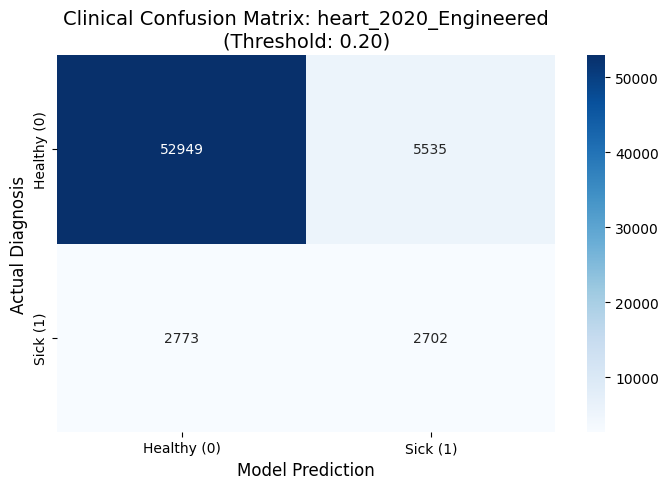


Dataset: heart_2020_Engineered
Accuracy: 0.8701
Precision: 0.328
Recall: 0.4935
F1 Score: 0.3941
ROC-AUC: 0.8387
Threshold: 0.19999999999999996


In [4]:
import pandas as pd
import numpy as np
import warnings
import optuna
import joblib 
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             precision_score, recall_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

optuna.logging.set_verbosity(optuna.logging.INFO)
warnings.filterwarnings('ignore')

SEED = 42

# --- 1. ADVANCED FEATURE ENGINEERING (THE SECRET TO HIGHER AUC) ---

def add_advanced_clinical_features(df):
    """Injects medical domain knowledge into the dataset to boost ROC-AUC."""
    print("  -> Engineering Advanced Clinical Features...")
    df_engineered = df.copy()
    new_cols = []
    
    # 1. Comorbidity Score (Compounding Risk)
    conditions = ['Stroke', 'Diabetic', 'Asthma', 'KidneyDisease', 'SkinCancer']
    existing_conds = [c for c in conditions if c in df_engineered.columns]
    
    if existing_conds:
        # Convert 'Yes'/'No' to 1/0 and sum them up
        df_engineered['Comorbidity_Score'] = df_engineered[existing_conds].apply(
            lambda x: x.map({'Yes': 1, 'No': 0, 'Yes (during pregnancy)': 1, 'No, borderline diabetes': 0}).fillna(0)
        ).sum(axis=1)
        new_cols.append('Comorbidity_Score')

    # 2. Metabolic Hazard Flag (The Deadly Trio)
    if all(c in df_engineered.columns for c in ['Smoking', 'PhysicalActivity', 'BMI']):
        df_engineered['Metabolic_Hazard'] = (
            (df_engineered['Smoking'] == 'Yes') & 
            (df_engineered['PhysicalActivity'] == 'No') & 
            (df_engineered['BMI'] > 30.0)
        ).astype(int)
        new_cols.append('Metabolic_Hazard')
        
    # 3. Age Ordinal Mapping (Teaching the AI that age is continuous)
    if 'AgeCategory' in df_engineered.columns:
        age_mapping = {
            '18-24': 0, '25-29': 1, '30-34': 2, '35-39': 3, '40-44': 4, 
            '45-49': 5, '50-54': 6, '55-59': 7, '60-64': 8, '65-69': 9, 
            '70-74': 10, '75-79': 11, '80 or older': 12
        }
        df_engineered['Age_Numeric'] = df_engineered['AgeCategory'].map(age_mapping)
        new_cols.append('Age_Numeric')
        
    # 4. Sleep Deprivation/Excess Factor
    if 'SleepTime' in df_engineered.columns:
        # Healthy sleep is usually 7-8 hours. Deviations are bad.
        df_engineered['Sleep_Deviation'] = abs(df_engineered['SleepTime'] - 7.5)
        new_cols.append('Sleep_Deviation')

    print(f"  -> Successfully added {len(new_cols)} new Medical Features: {new_cols}")
    return df_engineered

# --- 2. STANDARD DATA PREP ---

def get_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_cols)
    ])

def _best_threshold(y_true, prob, optimize_for="f1"):
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_t = 0.5
    best_score = 0.0
    if optimize_for == "f1":
        scores = [f1_score(y_true, (prob >= t).astype(int)) for t in thresholds]
        best_idx = int(np.argmax(scores))
        best_t, best_score = float(thresholds[best_idx]), float(scores[best_idx])
    return best_t, best_score, 0.0 

# --- 3. OPTUNA TUNING (FAST SHRINK & SMOTE) ---

def tune_hyperparameters(X_train, y_train, is_imbalanced, n_trials=10):
    print(f"  -> Tuning models using Optuna ({n_trials} trials per model)...")
    scorer = 'f1' if is_imbalanced else 'accuracy'
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED) 
    
    fast_smote_pipeline = [
        ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)),
        ('smote', SMOTE(sampling_strategy=1.0, random_state=SEED))
    ]

    def xgb_objective(trial):
        param = {
            "tree_method": "hist", "device": "cuda", "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 15), 
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        }
        model = xgb.XGBClassifier(**param)
        steps = fast_smote_pipeline + [('model', model)] if is_imbalanced else [('model', model)]
        pipe = ImbPipeline(steps)
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    def lgb_objective(trial):
        param = {
            "device": "gpu", "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 15), 
            "min_child_samples": trial.suggest_int("min_child_samples", 1, 10),
        }
        model = lgb.LGBMClassifier(**param)
        steps = fast_smote_pipeline + [('model', model)] if is_imbalanced else [('model', model)]
        pipe = ImbPipeline(steps)
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    def rf_objective(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 200),
            "max_depth": trial.suggest_int("max_depth", 5, 15), 
            "random_state": SEED, "n_jobs": -1
        }
        model = RandomForestClassifier(**param)
        steps = fast_smote_pipeline + [('model', model)] if is_imbalanced else [('model', model)]
        pipe = ImbPipeline(steps)
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    db_name = "sqlite:///optuna_tuning_checkpoints.db"

    print("\n--- Tuning XGBoost ---")
    xgb_study = optuna.create_study(study_name="xgb_heart_fe", storage=db_name, load_if_exists=True, direction="maximize")
    xgb_study.optimize(xgb_objective, n_trials=n_trials)
    
    print("\n--- Tuning LightGBM ---")
    lgb_study = optuna.create_study(study_name="lgb_heart_fe", storage=db_name, load_if_exists=True, direction="maximize")
    lgb_study.optimize(lgb_objective, n_trials=n_trials)
    
    print("\n--- Tuning Random Forest ---")
    rf_study = optuna.create_study(study_name="rf_heart_fe", storage=db_name, load_if_exists=True, direction="maximize")
    rf_study.optimize(rf_objective, n_trials=n_trials)
    
    xgb_tuned = xgb.XGBClassifier(**xgb_study.best_params, tree_method="hist", device="cuda", random_state=SEED)
    lgb_tuned = lgb.LGBMClassifier(**lgb_study.best_params, device="gpu", random_state=SEED)
    rf_tuned = RandomForestClassifier(**rf_study.best_params, random_state=SEED, n_jobs=-1)
    cat_tuned = CatBoostClassifier(task_type="GPU", depth=6, verbose=False, random_state=SEED)
    
    return [xgb_tuned, lgb_tuned, rf_tuned, cat_tuned]

# --- 4. STACKING PIPELINE ---

def run_rigorous_tuned_stacking(X, y, dataset_name):
    print(f"\n{'='*70}\nStarting Rigorous Evaluation: {dataset_name}\n{'='*70}")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    
    imbalance_ratio = y_train.value_counts().min() / y_train.value_counts().max()
    is_imbalanced = imbalance_ratio < 0.30
    target_metric = "f1" 
    
    print(f"Dataset Ratio: {imbalance_ratio:.2f} | Strategy: Feature Engineering + SMOTE")

    prep = get_preprocessor(X_train)
    X_train_proc = prep.fit_transform(X_train)
    X_test_proc = prep.transform(X_test)
    
    tuned_models = tune_hyperparameters(X_train_proc, y_train, is_imbalanced, n_trials=10)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros((X_train_proc.shape[0], 4)) 
    
    print("\n  -> Generating OOF Predictions...")
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_proc, y_train)):
        X_tr, X_va = X_train_proc[tr_idx], X_train_proc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        
        if is_imbalanced:
            rus = RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)
            smt = SMOTE(sampling_strategy=1.0, random_state=SEED)
            X_tr_rus, y_tr_rus = rus.fit_resample(X_tr, y_tr)
            X_tr_fit, y_tr_fit = smt.fit_resample(X_tr_rus, y_tr_rus)
        else:
            X_tr_fit, y_tr_fit = X_tr, y_tr
            
        for i, model in enumerate(tuned_models):
            model.fit(X_tr_fit, y_tr_fit)
            oof_preds[va_idx, i] = model.predict_proba(X_va)[:, 1]

    print("  -> Training Calibrated Meta-Model...")
    cw = "balanced" if is_imbalanced else None
    meta_model = LogisticRegression(class_weight=cw, random_state=SEED)
    meta_model.fit(oof_preds, y_train) 
    
    calibrated_meta = CalibratedClassifierCV(meta_model, method="isotonic", cv="prefit")
    calibrated_meta.fit(oof_preds, y_train)
    
    val_probs = calibrated_meta.predict_proba(oof_preds)[:, 1]
    best_t, best_val_score, _ = _best_threshold(y_train, val_probs, optimize_for=target_metric)

    print("  -> Training Final Ensembles on Full Train Set...")
    if is_imbalanced:
        rus = RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)
        smt = SMOTE(sampling_strategy=1.0, random_state=SEED)
        X_train_rus, y_train_rus = rus.fit_resample(X_train_proc, y_train)
        X_train_final, y_train_final = smt.fit_resample(X_train_rus, y_train_rus)
    else:
        X_train_final, y_train_final = X_train_proc, y_train
        
    for model in tuned_models:
        model.fit(X_train_final, y_train_final)
    
    test_feats = np.column_stack([m.predict_proba(X_test_proc)[:, 1] for m in tuned_models])
    test_probs = calibrated_meta.predict_proba(test_feats)[:, 1]
    test_preds = (test_probs >= best_t).astype(int)
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy (0)', 'Sick (1)'], 
                yticklabels=['Healthy (0)', 'Sick (1)'])
    plt.title(f"Clinical Confusion Matrix: {dataset_name}\n(Threshold: {best_t:.2f})", fontsize=14)
    plt.ylabel('Actual Diagnosis', fontsize=12)
    plt.xlabel('Model Prediction', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": round(accuracy_score(y_test, test_preds), 4),
        "Precision": round(precision_score(y_test, test_preds), 4),
        "Recall": round(recall_score(y_test, test_preds), 4),
        "F1 Score": round(f1_score(y_test, test_preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4),
        "Threshold": best_t
    }
    
    print("\n" + "=" * 40)
    for k, v in metrics.items():
        print(f"{k}: {v}")
    print("=" * 40)
    
    return metrics

# --- EXECUTION ---
if "heart_2020" in DATA_PATHS and Path(DATA_PATHS["heart_2020"]).exists():
    path = DATA_PATHS["heart_2020"]
    df = pd.read_csv(path, sep=',') 
    
    # Apply Feature Engineering First!
    df_engineered = add_advanced_clinical_features(df)
    
    X = df_engineered.drop(columns=['HeartDisease'])
    y = df_engineered['HeartDisease'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(df_engineered['HeartDisease']).astype(int)
    
    print(f"\n\n{'*'*50}")
    print(f"KICKING OFF ADVANCED PIPELINE")
    print(f"{'*'*50}")
    
    heart_2020_metrics = run_rigorous_tuned_stacking(X, y, "heart_2020_Engineered")


Starting PARADOX MASTER Pipeline: heart_2020_Final_Paradox


[I 2026-04-04 10:36:58,975] A new study created in RDB with name: xgb_v_final
[I 2026-04-04 10:37:09,487] Trial 0 finished with value: 0.38245006929277653 and parameters: {'learning_rate': 0.12885858595962923, 'max_depth': 4, 'min_child_weight': 7}. Best is trial 0 with value: 0.38245006929277653.
[I 2026-04-04 10:37:13,645] Trial 1 finished with value: 0.3804558701679445 and parameters: {'learning_rate': 0.24849991568716587, 'max_depth': 6, 'min_child_weight': 2}. Best is trial 0 with value: 0.38245006929277653.
[I 2026-04-04 10:37:23,113] Trial 2 finished with value: 0.37360773413151177 and parameters: {'learning_rate': 0.04733615150439758, 'max_depth': 12, 'min_child_weight': 6}. Best is trial 0 with value: 0.38245006929277653.
[I 2026-04-04 10:37:26,775] Trial 3 finished with value: 0.38297259016618096 and parameters: {'learning_rate': 0.19966488089384019, 'max_depth': 5, 'min_child_weight': 7}. Best is trial 3 with value: 0.38297259016618096.
[I 2026-04-04 10:37:31,751] Trial 4 fi

[LightGBM] [Info] Number of positive: 29198, number of negative: 29198
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5474
[LightGBM] [Info] Number of data points in the train set: 58396, number of used features: 23
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (0.89 MB) transferred to GPU in 0.006664 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 29196, number of negative: 29196
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5467
[LightGBM] [Info] Number of data points in the train set: 58392, number of used features: 23
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB La

[I 2026-04-04 10:38:25,731] Trial 0 finished with value: 0.3805031586442938 and parameters: {'learning_rate': 0.2513973377963198, 'max_depth': 12}. Best is trial 0 with value: 0.3805031586442938.


[LightGBM] [Info] Number of positive: 29198, number of negative: 29198
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5474
[LightGBM] [Info] Number of data points in the train set: 58396, number of used features: 23
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (0.89 MB) transferred to GPU in 0.005889 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

...

[LightGBM] [Info] Number of positive: 29198, number of negative: 29198
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5474
[LightGBM] [Info] Number of data points in the train set: 58396, number of used features: 23
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (0.89 MB) transferred to GPU in 0.014957 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 29196, number of negative: 29196
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5467
[LightGBM] [Info] Number of data points in the train set: 58392, number of used features: 23
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB La

[I 2026-04-04 10:39:39,123] Trial 8 finished with value: 0.37895242353966774 and parameters: {'learning_rate': 0.2854621344362813, 'max_depth': 12}. Best is trial 7 with value: 0.3851016236930884.


[LightGBM] [Info] Number of positive: 29198, number of negative: 29198
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5474
[LightGBM] [Info] Number of data points in the train set: 58396, number of used features: 23
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (0.89 MB) transferred to GPU in 0.007048 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-04 10:39:51,590] Trial 9 finished with value: 0.38301236529173055 and parameters: {'learning_rate': 0.11814173774436838, 'max_depth': 4}. Best is trial 7 with value: 0.3851016236930884.
[I 2026-04-04 10:39:51,817] A new study created in RDB with name: rf_v_final
[I 2026-04-04 10:40:22,018] Trial 0 finished with value: 0.3710834085788998 and parameters: {'n_estimators': 175, 'max_depth': 10}. Best is trial 0 with value: 0.3710834085788998.
[I 2026-04-04 10:40:37,158] Trial 1 finished with value: 0.3707502844331958 and parameters: {'n_estimators': 128, 'max_depth': 10}. Best is trial 0 with value: 0.3710834085788998.
[I 2026-04-04 10:40:48,664] Trial 2 finished with value: 0.3597614612782078 and parameters: {'n_estimators': 154, 'max_depth': 6}. Best is trial 0 with value: 0.3710834085788998.
[I 2026-04-04 10:41:22,922] Trial 3 finished with value: 0.3735218353740599 and parameters: {'n_estimators': 195, 'max_depth': 11}. Best is trial 3 with value: 0.3735218353740599.
[I 2026

  -> Generating OOF Predictions...
[LightGBM] [Info] Number of positive: 35036, number of negative: 35036
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5463
[LightGBM] [Info] Number of data points in the train set: 70072, number of used features: 23
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (0.80 MB) transferred to GPU in 0.012333 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 35038, number of negative: 35038
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5470
[LightGBM] [Info] Number of data points in the train set: 70076, number of used features: 23
[LightGBM] [Info] Using GPU Dev

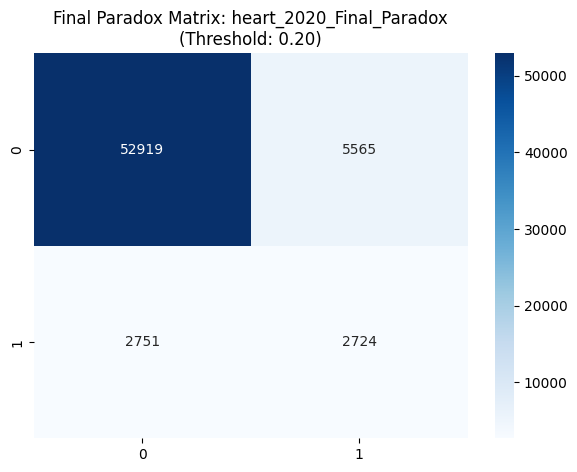

  -> ✅ Model saved as: paradox_master_model.pkl

--- FINAL PARADOX METRICS ---
                    Dataset  Accuracy  Precision  Recall  ROC-AUC
0  heart_2020_Final_Paradox      0.87     0.3286  0.4975   0.8394


In [3]:
import pandas as pd
import numpy as np
import warnings
import optuna
import joblib 
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             precision_score, recall_score, confusion_matrix)

# ADVANCED IMPORTS
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import category_encoders as ce  

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

optuna.logging.set_verbosity(optuna.logging.INFO)
warnings.filterwarnings('ignore')

SEED = 42

# --- 1. ADVANCED FEATURE ENGINEERING (PARADOX ENGINE) ---

def add_advanced_clinical_features(df):
    df_engineered = df.copy()
    
    # Mapping for common boolean-style columns
    yes_no = {'Yes': 1, 'No': 0, 'Yes (during pregnancy)': 1, 'No, borderline diabetes': 0}
    
    # A. Core Conversions & Ratios (The 30-Day Scale)
    if 'PhysicalHealth' in df_engineered.columns:
        df_engineered['Phys_Unhealth_Ratio'] = df_engineered['PhysicalHealth'] / 30.0
    if 'MentalHealth' in df_engineered.columns:
        df_engineered['Ment_Unhealth_Ratio'] = df_engineered['MentalHealth'] / 30.0
        
    if 'AgeCategory' in df_engineered.columns:
        age_mapping = {
            '18-24': 0, '25-29': 1, '30-34': 2, '35-39': 3, '40-44': 4, 
            '45-49': 5, '50-54': 6, '55-59': 7, '60-64': 8, '65-69': 9, 
            '70-74': 10, '75-79': 11, '80 or older': 12
        }
        df_engineered['Age_Numeric'] = df_engineered['AgeCategory'].map(age_mapping)

    # B. Resilience Shield (Reducing False Positives)
    # Identifies people who have risk but strong protective lifestyle factors
    if all(c in df_engineered.columns for c in ['PhysicalActivity', 'SleepTime', 'Smoking']):
        phys = df_engineered['PhysicalActivity'].map(yes_no).fillna(0)
        smoke = df_engineered['Smoking'].map(yes_no).fillna(0)
        # Perfect sleep (7-8 hours) is a multiplier for resilience
        good_sleep = ((df_engineered['SleepTime'] >= 7) & (df_engineered['SleepTime'] <= 8)).astype(int)
        
        df_engineered['Resilience_Shield'] = (phys + good_sleep) - smoke

    # C. Hidden Risk Index (Reducing False Negatives)
    # Identifies young people with serious conditions (Proxy for Genetics/High Risk)
    if all(c in df_engineered.columns for c in ['Age_Numeric', 'Stroke', 'KidneyDisease']):
        stroke = df_engineered['Stroke'].map(yes_no).fillna(0)
        kidney = df_engineered['KidneyDisease'].map(yes_no).fillna(0)
        # If age < 35 (cat 0-3) and has Stroke/Kidney, Hidden Risk is massive
        df_engineered['Hidden_Genetic_Risk'] = ((df_engineered['Age_Numeric'] <= 3) & (stroke + kidney > 0)).astype(int)

    # D. Risk Inconsistency (The Delta)
    # High physical activity BUT high bad health days = Internal physiological strain
    if all(c in df_engineered.columns for c in ['PhysicalActivity', 'PhysicalHealth']):
        phys = df_engineered['PhysicalActivity'].map(yes_no).fillna(0)
        # Higher score = More inconsistent (Physically active but physically suffering)
        df_engineered['Unexplained_Strain'] = phys * (df_engineered['PhysicalHealth'] / 30.0)

    # Standard Comorbidity Score
    conditions = ['Stroke', 'Diabetic', 'Asthma', 'KidneyDisease', 'SkinCancer']
    existing_conds = [c for c in conditions if c in df_engineered.columns]
    if existing_conds:
        df_engineered['Comorbidity_Score'] = df_engineered[existing_conds].apply(
            lambda x: x.map(yes_no).fillna(0)
        ).sum(axis=1)

    return df_engineered

# --- 2. PREPROCESSOR WITH TARGET ENCODING ---

def get_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', ce.TargetEncoder(smoothing=10.0), cat_cols) 
    ])

def _best_threshold(y_true, prob, optimize_for="f1"):
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_t = 0.5
    best_score = 0.0
    if optimize_for == "f1":
        scores = [f1_score(y_true, (prob >= t).astype(int)) for t in thresholds]
        best_idx = int(np.argmax(scores))
        best_t, best_score = float(thresholds[best_idx]), float(scores[best_idx])
    return best_t, best_score, 0.0 

# --- 3. OPTUNA TUNING ---

def tune_hyperparameters(X_train, y_train, is_imbalanced, n_trials=10):
    scorer = 'f1' if is_imbalanced else 'accuracy'
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED) 
    
    fast_smote_pipeline = [
        ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)),
        ('smote', SMOTE(sampling_strategy=1.0, random_state=SEED))
    ]

    def xgb_objective(trial):
        param = {
            "tree_method": "hist", "device": "cuda", "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 12), 
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        }
        model = xgb.XGBClassifier(**param)
        steps = fast_smote_pipeline + [('model', model)] if is_imbalanced else [('model', model)]
        pipe = ImbPipeline(steps)
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    def lgb_objective(trial):
        param = {
            "device": "gpu", "random_state": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 12), 
        }
        model = lgb.LGBMClassifier(**param)
        steps = fast_smote_pipeline + [('model', model)] if is_imbalanced else [('model', model)]
        pipe = ImbPipeline(steps)
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    def rf_objective(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 200),
            "max_depth": trial.suggest_int("max_depth", 5, 12), 
            "random_state": SEED, "n_jobs": -1
        }
        model = RandomForestClassifier(**param)
        steps = fast_smote_pipeline + [('model', model)] if is_imbalanced else [('model', model)]
        pipe = ImbPipeline(steps)
        return cross_val_score(pipe, X_train, y_train, scoring=scorer, cv=skf).mean()

    db_name = "sqlite:///optuna_final_master.db"

    xgb_study = optuna.create_study(study_name="xgb_v_final", storage=db_name, load_if_exists=True, direction="maximize")
    xgb_study.optimize(xgb_objective, n_trials=n_trials)
    
    lgb_study = optuna.create_study(study_name="lgb_v_final", storage=db_name, load_if_exists=True, direction="maximize")
    lgb_study.optimize(lgb_objective, n_trials=n_trials)
    
    rf_study = optuna.create_study(study_name="rf_v_final", storage=db_name, load_if_exists=True, direction="maximize")
    rf_study.optimize(rf_objective, n_trials=n_trials)
    
    xgb_tuned = xgb.XGBClassifier(**xgb_study.best_params, tree_method="hist", device="cuda", random_state=SEED)
    lgb_tuned = lgb.LGBMClassifier(**lgb_study.best_params, device="gpu", random_state=SEED)
    rf_tuned = RandomForestClassifier(**rf_study.best_params, random_state=SEED, n_jobs=-1)
    cat_tuned = CatBoostClassifier(task_type="GPU", depth=6, verbose=False, random_state=SEED)
    
    return [xgb_tuned, lgb_tuned, rf_tuned, cat_tuned]

# --- 4. MASTER EVALUATION & SAVING ---

def run_rigorous_tuned_stacking(X, y, dataset_name):
    print(f"\n{'='*70}\nStarting PARADOX MASTER Pipeline: {dataset_name}\n{'='*70}")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    is_imbalanced = (y_train.value_counts().min() / y_train.value_counts().max()) < 0.30

    prep = get_preprocessor(X_train)
    X_train_proc = prep.fit_transform(X_train, y_train) 
    X_test_proc = prep.transform(X_test)
    
    tuned_models = tune_hyperparameters(X_train_proc, y_train, is_imbalanced, n_trials=10)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros((X_train_proc.shape[0], 4)) 
    
    print("  -> Generating OOF Predictions...")
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_proc, y_train)):
        X_tr, X_va = X_train_proc[tr_idx], X_train_proc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        
        if is_imbalanced:
            rus = RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)
            smt = SMOTE(sampling_strategy=1.0, random_state=SEED)
            X_tr_rus, y_tr_rus = rus.fit_resample(X_tr, y_tr)
            X_tr_fit, y_tr_fit = smt.fit_resample(X_tr_rus, y_tr_rus)
        else:
            X_tr_fit, y_tr_fit = X_tr, y_tr
            
        for i, model in enumerate(tuned_models):
            # CatBoost requires explicit integer target
            model.fit(X_tr_fit, np.array(y_tr_fit).astype(int))
            oof_preds[va_idx, i] = model.predict_proba(X_va)[:, 1]

    print("  -> Training Calibrated Meta-Model...")
    meta_model = LogisticRegression(class_weight="balanced" if is_imbalanced else None, random_state=SEED)
    meta_model.fit(oof_preds, y_train) 
    
    calibrated_meta = CalibratedClassifierCV(meta_model, method="isotonic", cv="prefit")
    calibrated_meta.fit(oof_preds, y_train)
    
    val_probs = calibrated_meta.predict_proba(oof_preds)[:, 1]
    best_t, _, _ = _best_threshold(y_train, val_probs, optimize_for="f1")

    print("  -> Training Final Ensembles on Full Train Set...")
    if is_imbalanced:
        rus = RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)
        smt = SMOTE(sampling_strategy=1.0, random_state=SEED)
        X_tr_rus, y_tr_rus = rus.fit_resample(X_train_proc, y_train)
        X_final_fit, y_final_fit = smt.fit_resample(X_tr_rus, y_tr_rus)
    else:
        X_final_fit, y_final_fit = X_train_proc, y_train
        
    for model in tuned_models:
        model.fit(X_final_fit, np.array(y_final_fit).astype(int))
    
    test_feats = np.column_stack([m.predict_proba(X_test_proc)[:, 1] for m in tuned_models])
    test_probs = calibrated_meta.predict_proba(test_feats)[:, 1]
    test_preds = (test_probs >= best_t).astype(int)
    
    # OUTPUT RESULTS
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Final Paradox Matrix: {dataset_name}\n(Threshold: {best_t:.2f})")
    plt.show()
    
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": round(accuracy_score(y_test, test_preds), 4),
        "Precision": round(precision_score(y_test, test_preds), 4),
        "Recall": round(recall_score(y_test, test_preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4)
    }
    
    # SAVE THE FINAL MODEL
    model_artifact = {
        "preprocessor": prep, "base_models": tuned_models,
        "meta_model": calibrated_meta, "threshold": best_t,
        "features": X.columns.tolist()
    }
    joblib.dump(model_artifact, f"paradox_master_model.pkl")
    print(f"  -> ✅ Model saved as: paradox_master_model.pkl")
    
    return metrics

# --- EXECUTION ---
if "heart_2020" in DATA_PATHS:
    df = pd.read_csv(DATA_PATHS["heart_2020"])
    
    # Run Advanced Feature Engineering with Paradox Factors
    df_engineered = add_advanced_clinical_features(df)
    
    X = df_engineered.drop(columns=['HeartDisease', 'AgeCategory'], errors='ignore')
    y = df_engineered['HeartDisease'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(df_engineered['HeartDisease']).astype(int)
    
    final_metrics = run_rigorous_tuned_stacking(X, y, "heart_2020_Final_Paradox")
    print("\n--- FINAL PARADOX METRICS ---")
    print(pd.DataFrame([final_metrics]))

In [5]:
import pandas as pd
import numpy as np
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, f1_score

warnings.filterwarnings('ignore')
SEED = 42

# --- 1. THE FEATURE FACTORY ---
def apply_heart_2020_logic(df):
    df_temp = df.copy()
    yes_no = {'Yes': 1, 'No': 0, 'Yes (during pregnancy)': 1, 'No, borderline diabetes': 0}
    
    # Ratios
    if 'PhysicalHealth' in df_temp.columns:
        df_temp['Phys_Unhealth_Ratio'] = df_temp['PhysicalHealth'] / 30.0
    if 'MentalHealth' in df_temp.columns:
        df_temp['Ment_Unhealth_Ratio'] = df_temp['MentalHealth'] / 30.0
    
    # Age
    age_mapping = {'18-24': 0, '25-29': 1, '30-34': 2, '35-39': 3, '40-44': 4, 
                   '45-49': 5, '50-54': 6, '55-59': 7, '60-64': 8, '65-69': 9, 
                   '70-74': 10, '75-79': 11, '80 or older': 12}
    if 'AgeCategory' in df_temp.columns:
        df_temp['Age_Numeric'] = df_temp['AgeCategory'].map(age_mapping)

    # Paradox Logic
    if all(c in df_temp.columns for c in ['PhysicalActivity', 'SleepTime', 'Smoking']):
        phys = df_temp['PhysicalActivity'].map(yes_no).fillna(0)
        smoke = df_temp['Smoking'].map(yes_no).fillna(0)
        good_sleep = ((df_temp['SleepTime'] >= 7) & (df_temp['SleepTime'] <= 8)).astype(int)
        df_temp['Resilience_Shield'] = (phys + good_sleep) - smoke
        df_temp['Unexplained_Strain'] = phys * (df_temp['PhysicalHealth'] / 30.0)

    if all(c in df_temp.columns for c in ['Age_Numeric', 'Stroke', 'KidneyDisease']):
        stroke = df_temp['Stroke'].map(yes_no).fillna(0)
        kidney = df_temp['KidneyDisease'].map(yes_no).fillna(0)
        df_temp['Hidden_Genetic_Risk'] = ((df_temp['Age_Numeric'] <= 3) & (stroke + kidney > 0)).astype(int)

    return df_temp

# --- 2. THE UPDATED CONSENSUS ENGINE ---
class ConsensusEngine:
    def __init__(self, paths):
        self.experts = {name: joblib.load(path) for name, path in paths.items()}
        print(f"✅ Experts Ready: {list(self.experts.keys())}")

    def _align(self, df, required_features):
        df_aligned = df.copy()
        for col in required_features:
            if col not in df_aligned.columns:
                df_aligned[col] = 0 
        return df_aligned[required_features]

    def evaluate_with_threshold(self, X_test, y_test, dataset_name, threshold=0.5):
        results = []
        expert_probs = {}

        for name, art in self.experts.items():
            X_input = self._align(X_test, art['features'])
            X_proc = art['preprocessor'].transform(X_input)
            
            # Predict
            probs = np.column_stack([m.predict_proba(X_proc)[:, 1] for m in art['base_models']])
            p = art['meta_model'].predict_proba(probs)[:, 1]
            expert_probs[name] = p
            
            # Apply Threshold
            preds = (p >= threshold).astype(int)
            
            results.append({
                'Test_Data': dataset_name, 
                'Model': f"Expert: {name}",
                'Threshold': threshold,
                'Accuracy': accuracy_score(y_test, preds),
                'Recall': recall_score(y_test, preds),
                'ROC-AUC': roc_auc_score(y_test, p)
            })

        # Final Consensus Calculation
        consensus_p = np.mean(list(expert_probs.values()), axis=0)
        con_preds = (consensus_p >= threshold).astype(int)
        
        results.append({
            'Test_Data': dataset_name, 
            'Model': 'TRIPLE-VOTE CONSENSUS',
            'Threshold': threshold,
            'Accuracy': accuracy_score(y_test, con_preds),
            'Recall': recall_score(y_test, con_preds),
            'ROC-AUC': roc_auc_score(y_test, consensus_p)
        })
        return results

# --- 3. EXECUTION ---
model_paths = {
    'Paradox_2020': 'paradox_master_model.pkl',
    'Cardio_Expert': 'stacking_model_cardio_train.pkl',
    'Statlog_Expert': 'stacking_model_heart_statlog.pkl'
}
engine = ConsensusEngine(model_paths)
all_metrics = []

# Dataset 1: Heart 2020 (USING 0.18 THRESHOLD)
df1 = apply_heart_2020_logic(pd.read_csv(DATA_PATHS["heart_2020"]))
X1 = df1.drop(columns=['HeartDisease', 'AgeCategory'], errors='ignore')
y1 = df1['HeartDisease'].map({'Yes': 1, 'No': 0, 1:1, 0:0}).fillna(0).astype(int)
_, X_t1, _, y_t1 = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=SEED)
all_metrics.extend(engine.evaluate_with_threshold(X_t1, y_t1, "Heart_2020", threshold=0.18))

# Dataset 2: Cardio Train (USING 0.50 THRESHOLD)
df2 = pd.read_csv(DATA_PATHS["cardio_train"], sep=';')
X2 = df2.drop(columns=['cardio'])
y2 = df2['cardio']
_, X_t2, _, y_t2 = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=SEED)
all_metrics.extend(engine.evaluate_with_threshold(X_t2, y_t2, "Cardio_Train", threshold=0.5))

# Dataset 3: Heart Statlog (USING 0.50 THRESHOLD)
df3 = pd.read_csv(DATA_PATHS["heart_statlog"])
X3 = df3.drop(columns=['target'])
y3 = df3['target']
_, X_t3, _, y_t3 = train_test_split(X3, y3, test_size=0.2, stratify=y3, random_state=SEED)
all_metrics.extend(engine.evaluate_with_threshold(X_t3, y_t3, "Heart_Statlog", threshold=0.5))

# --- 4. DISPLAY RESULTS ---
final_df = pd.DataFrame(all_metrics)
print("\n" + "="*95)
print("FINAL CROSS-DOMAIN STRESS TEST (WITH CUSTOM THRESHOLDS)")
print("="*95)
print(final_df.sort_values(by=['Test_Data', 'ROC-AUC'], ascending=[True, False]).to_string(index=False))

✅ Experts Ready: ['Paradox_2020', 'Cardio_Expert', 'Statlog_Expert']

FINAL CROSS-DOMAIN STRESS TEST (WITH CUSTOM THRESHOLDS)
    Test_Data                  Model  Threshold  Accuracy   Recall  ROC-AUC
 Cardio_Train  Expert: Cardio_Expert       0.50  0.722071 0.581332 0.797702
 Cardio_Train  TRIPLE-VOTE CONSENSUS       0.50  0.700000 0.853774 0.797702
 Cardio_Train   Expert: Paradox_2020       0.50  0.499714 1.000000 0.500000
 Cardio_Train Expert: Statlog_Expert       0.50  0.500286 0.000000 0.500000
   Heart_2020   Expert: Paradox_2020       0.18  0.867837 0.501918 0.837556
   Heart_2020  TRIPLE-VOTE CONSENSUS       0.18  0.915164 0.015708 0.837556
   Heart_2020  Expert: Cardio_Expert       0.18  0.914398 0.000000 0.500000
   Heart_2020 Expert: Statlog_Expert       0.18  0.914398 0.000000 0.500000
Heart_Statlog Expert: Statlog_Expert       0.50  0.915966 0.944444 0.955818
Heart_Statlog  TRIPLE-VOTE CONSENSUS       0.50  0.878151 0.960317 0.935622
Heart_Statlog   Expert: Paradox_2020  